In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=5

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=5


In [1]:
import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate

device = 'cuda'

In [3]:
from sda.mcs import KolmogorovFlow

In [1]:
model =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_37/best_model.pth')
model.load_state_dict(checkpoint)

NameError: name 'DiffusionModel' is not defined

In [5]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 32,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 256
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


### How the frequencies of the x0 estimate are built over time

In [6]:
model.eval()

statistics_eval_mode = {}

with torch.no_grad():
    for batch_idx, sample in enumerate(val_loader):
        if batch_idx ==2: continue
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        
        prediction1, x0_estimates = model(conditioning_frame, require_x0_estimate = True)
        if batch_idx ==3 : break

In [7]:
x0_estimates.shape

torch.Size([100, 256, 2, 32, 32])

In [10]:
### Rate of change of the FFT of the prediction

import torch
x = x0_estimates
# x: (T, B, C, H, W)
T, B, C, H, W = x.shape

x_fft = torch.fft.fftn(x, dim=(-2, -1))   # (T, B, C, H, W), complex

dt = 1.0  # or your actual Δt
dx_fft_dt = torch.abs((x_fft[1:] - x_fft[:-1]) / x_fft[1:])   # shape (T-1, B, C, H, W)

kx = torch.fft.fftfreq(H) * H
ky = torch.fft.fftfreq(W) * W
KX, KY = torch.meshgrid(kx, ky, indexing="ij")
r = torch.sqrt(KX**2 + KY**2)        # radius per frequency
r_int = r.to(torch.int64)            # integer bins
r_max = int(r_int.max().item())

# flatten spatial dims
dx_fft_dt_flat = dx_fft_dt.reshape(T-1, B, C, -1)   # (T-1, B, C, H*W)
r_flat = r_int.flatten()                            # (H*W,)

# Prepare container: complex result
radial_dx = dx_fft_dt_flat.new_zeros((T-1, B, C, r_max+1), dtype=dx_fft_dt_flat.dtype)

for radius in range(r_max+1):
    mask = (r_flat == radius)
    if mask.any():
        radial_dx[..., radius] = dx_fft_dt_flat[..., mask].mean(dim=-1)

In [11]:
target_frame.shape

torch.Size([256, 2, 32, 32])

In [12]:
x.shape

torch.Size([100, 256, 2, 32, 32])

In [13]:
### Rate of convergence of the distance between FFT of prediction and FFT of target

import torch
x = x0_estimates
# x: (T, B, C, H, W)
T, B, C, H, W = x.shape

x_fft = torch.fft.fftn(x, dim=(-2, -1))   # (T, B, C, H, W), complex
target_fft = torch.fft.fftn(target_frame, dim=(-2, -1))

dt = 1.0  # or your actual Δt
d_fft_x_target = torch.abs((x_fft - target_fft)/target_fft)  # shape (T-1, B, C, H, W)

d_fft_x_target = torch.abs((x_fft - target_fft)/target_fft)

kx = torch.fft.fftfreq(H) * H
ky = torch.fft.fftfreq(W) * W
KX, KY = torch.meshgrid(kx, ky, indexing="ij")
r = torch.sqrt(KX**2 + KY**2)        # radius per frequency
r_int = r.to(torch.int64)            # integer bins
r_max = int(r_int.max().item())

# flatten spatial dims
dx_fft_dt_flat = dx_fft_dt.reshape(T-1, B, C, -1)   # (T-1, B, C, H*W)
r_flat = r_int.flatten()                            # (H*W,)

# Prepare container: complex result
radial_dx = dx_fft_dt_flat.new_zeros((T-1, B, C, r_max+1), dtype=dx_fft_dt_flat.dtype)

for radius in range(r_max+1):
    mask = (r_flat == radius)
    if mask.any():
        radial_dx[..., radius] = dx_fft_dt_flat[..., mask].mean(dim=-1)

In [11]:
target_fft.shape

torch.Size([256, 2, 32, 32])

In [16]:
mean_dx_fft_dt = torch.mean(dx_fft_dt, axis=1)

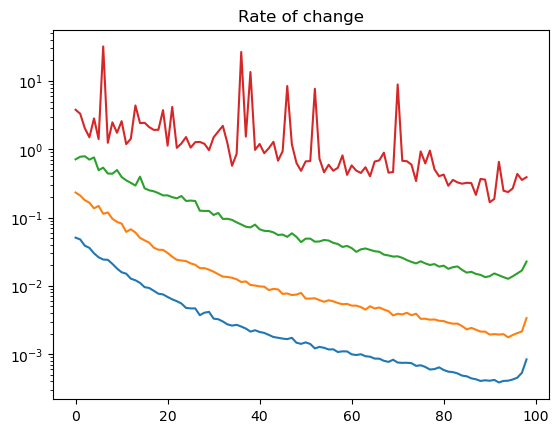

In [18]:
plt.plot(mean_dx_fft_dt[:,0,1,1].real.cpu())
plt.plot(mean_dx_fft_dt[:,0,4,4].real.cpu())
plt.plot(mean_dx_fft_dt[:,0,8,8].real.cpu())
plt.plot(mean_dx_fft_dt[:,0,16,16].real.cpu())
#plt.plot(mean_dx_fft_dt[:,0,24,24].real.cpu())
#plt.plot(mean_dx_fft_dt[:,0,32,32].real.cpu())

plt.title("Rate of change")
plt.yscale("log")

In [19]:
mean_dx_fft_dt = torch.mean(d_fft_x_target, axis=1)

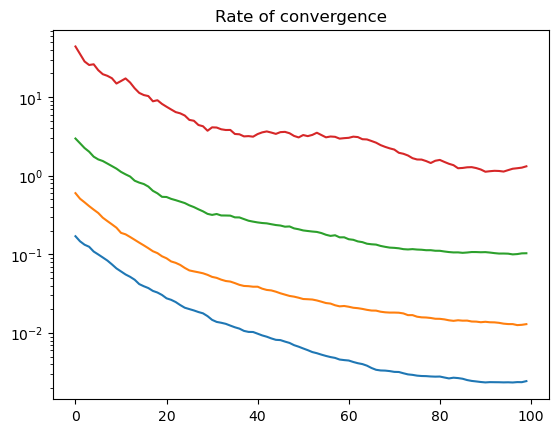

In [21]:
plt.plot(mean_dx_fft_dt[:,0,1,1].real.cpu())
plt.plot(mean_dx_fft_dt[:,0,4,4].real.cpu())
plt.plot(mean_dx_fft_dt[:,0,8,8].real.cpu())
plt.plot(mean_dx_fft_dt[:,0,16,16].real.cpu())
#plt.plot(mean_dx_fft_dt[:,0,24,24].real.cpu())
#plt.plot(mean_dx_fft_dt[:,0,32,32].real.cpu())

plt.title("Rate of convergence")
plt.yscale("log")

In [11]:
import torch

def optimal_freqwise_mix_fft(x, Y, Z, eps=1e-12, real=False, clamp01=False):
    """
    Compute optimal frequency-wise mixing coefficients.
    
    x: (T, B, C, H, W)
    Y: (B, C, H, W)
    Z: (B, C, H, W)
    
    Returns:
      c: (T, C, H, W) coefficients (complex or real depending on options)
      Zhat: (T, B, C, H, W) reconstructed FFTs
    """
    # Ensure complex dtype
    x_c = x if torch.is_complex(x) else x.to(torch.complex64)
    Y_c = Y if torch.is_complex(Y) else Y.to(torch.complex64)
    Z_c = Z if torch.is_complex(Z) else Z.to(torch.complex64)

    # FFTs
    F = torch.fft.fftn(x_c, dim=(-2, -1))   # (T,B,C,H,W)
    FY = torch.fft.fftn(Y_c, dim=(-2, -1))  # (B,C,H,W)
    Zfft = torch.fft.fftn(Z_c, dim=(-2, -1))# (B,C,H,W)

    # Broadcast
    FY_tb = FY.unsqueeze(0).expand(F.shape) 
    Z_tb  = Zfft.unsqueeze(0).expand(F.shape)

    # Define A, B
    A = F - FY_tb            # (T,B,C,H,W)
    B = Z_tb - FY_tb         # (T,B,C,H,W), independent of t

    # Numerator and denominator reduced over batch only
    num = torch.sum(A.conj() * B, dim=1)            # (T,C,H,W)
    denom = torch.sum(A.real**2 + A.imag**2, dim=1) # (T,C,H,W)

    if real:
        c = num.real / (denom + eps)  # (T,C,H,W)
        if clamp01:
            c = c.clamp(0, 1)
    else:
        c = num / (denom + eps)       # (T,C,H,W), complex

    # Reconstruct
    c_expanded = c.unsqueeze(1)  # (T,1,C,H,W)
    Zhat = c_expanded * F + (1 - c_expanded) * FY_tb

    return c, Zhat


In [12]:
_, linear_comb_fft = optimal_global_mix_fft(x0_estimates[:-1], target_frame, x0_estimates[-1])

NameError: name 'optimal_global_mix_fft' is not defined

In [14]:
import torch

def optimal_freqwise_mix_and_image_distances(
    x,         # (T, B, C, H, W) real or complex
    Y,         # (B, C, H, W)
    Z,         # (B, C, H, W)
    eps=1e-12,
    real=False,
    clamp01=False,
    reduction="mean",   # "mean" or "sum"
    device=None
):
    """
    Returns:
      c: (T, C, H, W) complex (or real if real=True) optimal coefficients
      distances: (T,) distance in image domain (MSE if reduction="mean", else sum of squared error)
      Zhat_img: (T, B, C, H, W) reconstructed images (real)
    """
    if device is None:
        device = x.device

    # ensure complex dtype for FFT math
    dtype = torch.complex64
    x_c = x.to(dtype) if not torch.is_complex(x) else x
    Y_c = Y.to(dtype) if not torch.is_complex(Y) else Y
    Z_c = Z.to(dtype) if not torch.is_complex(Z) else Z

    # FFT spatial dims
    F = torch.fft.fftn(x_c, dim=(-2, -1))    # (T, B, C, H, W)
    FY = torch.fft.fftn(Y_c, dim=(-2, -1))   # (B, C, H, W)
    Zfft = torch.fft.fftn(Z_c, dim=(-2, -1)) # (B, C, H, W)

    # Broadcast FY and Zfft over time T
    FY_tb = FY.unsqueeze(0).expand(F.shape)  # (T, B, C, H, W)
    Z_tb  = Zfft.unsqueeze(0).expand(F.shape) # (T, B, C, H, W)

    # A = F - FY, B = Z - FY (B independent of T, but expanded)
    A = F - FY_tb       # (T, B, C, H, W)
    B = Z_tb - FY_tb    # (T, B, C, H, W)

    # Numerator and denominator summed over batch only (dim=1)
    # num = sum_b A*^ B  (complex)
    num = torch.sum(A.conj() * B, dim=1)              # (T, C, H, W)
    denom = torch.sum(A.real**2 + A.imag**2, dim=1)   # (T, C, H, W)

    # solve for c (per t, c, h, w)
    if real:
        c = (num.real) / (denom + eps)                # real
        if clamp01:
            c = c.clamp(0.0, 1.0)
    else:
        c = num / (denom + eps)                       # complex

    # Reconstruct Zhat in Fourier domain:
    # c shape -> (T, 1, C, H, W) for broadcasting with F and FY_tb
    c_exp = c.unsqueeze(1)                            # (T,1,C,H,W)
    Zhat_fft = c_exp * F + (1.0 - c_exp) * FY_tb      # (T,B,C,H,W) complex

    # Inverse FFT to image domain
    # Zhat_img: (T,B,C,H,W), complex -> take real part (imag numerics)
    Zhat_img = torch.fft.ifftn(Zhat_fft, dim=(-2, -1)).real

    # True image Z: inverse FFT of Zfft (B,C,H,W) -> real
    Z_img = torch.fft.ifftn(Zfft, dim=(-2, -1)).real   # (B,C,H,W)
    Z_img_tb = Z_img.unsqueeze(0).expand_as(Zhat_img)  # (T,B,C,H,W)

    # Squared error in image domain
    err = (Zhat_img - Z_img_tb) ** 2                   # (T,B,C,H,W)

    if reduction == "mean":
        distances = err.mean(dim=(1,2,3,4))            # (T,)
    elif reduction == "sum":
        distances = err.sum(dim=(1,2,3,4))             # (T,)
    else:
        raise ValueError("reduction must be 'mean' or 'sum'")

    return c, distances, Zhat_img


In [15]:
import torch

def evaluate_freqwise_mix(
    x,         # (T, B, C, H, W) real or complex
    Y,         # (B, C, H, W)
    Z,         # (B, C, H, W)
    c,
    eps=1e-12,
    real=False,
    clamp01=False,
    reduction="mean",   # "mean" or "sum"
    device=None
):
    if device is None:
        device = x.device

    # ensure complex dtype for FFT math
    dtype = torch.complex64
    x_c = x.to(dtype) if not torch.is_complex(x) else x
    Y_c = Y.to(dtype) if not torch.is_complex(Y) else Y
    Z_c = Z.to(dtype) if not torch.is_complex(Z) else Z

    # FFT spatial dims
    F = torch.fft.fftn(x_c, dim=(-2, -1))    # (T, B, C, H, W)
    FY = torch.fft.fftn(Y_c, dim=(-2, -1))   # (B, C, H, W)
    Zfft = torch.fft.fftn(Z_c, dim=(-2, -1)) # (B, C, H, W)

    # Broadcast FY and Zfft over time T
    FY_tb = FY.unsqueeze(0).expand(F.shape)  # (T, B, C, H, W)
    Z_tb  = Zfft.unsqueeze(0).expand(F.shape) # (T, B, C, H, W)

    # Reconstruct Zhat in Fourier domain:
    # c shape -> (T, 1, C, H, W) for broadcasting with F and FY_tb
    c_exp = c.unsqueeze(1)                            # (T,1,C,H,W)
    Zhat_fft = c_exp * F + (1.0 - c_exp) * FY_tb      # (T,B,C,H,W) complex

    # Inverse FFT to image domain
    # Zhat_img: (T,B,C,H,W), complex -> take real part (imag numerics)
    Zhat_img = torch.fft.ifftn(Zhat_fft, dim=(-2, -1)).real

    # True image Z: inverse FFT of Zfft (B,C,H,W) -> real
    Z_img = torch.fft.ifftn(Zfft, dim=(-2, -1)).real   # (B,C,H,W)
    Z_img_tb = Z_img.unsqueeze(0).expand_as(Zhat_img)  # (T,B,C,H,W)

    # Squared error in image domain
    err = (Zhat_img - Z_img_tb) ** 2                   # (T,B,C,H,W)

    if reduction == "mean":
        distances = err.mean(dim=(1,2,3,4))            # (T,)
    elif reduction == "sum":
        distances = err.sum(dim=(1,2,3,4))             # (T,)
    else:
        raise ValueError("reduction must be 'mean' or 'sum'")

    return distances, Zhat_img

In [16]:
c, distances_freq_wise, estimated_combinations = optimal_freqwise_mix_and_image_distances(x0_estimates[:-1], target_frame, x0_estimates[-1])

In [17]:
distances_freq_wise

tensor([5.7081e-05, 5.7018e-05, 5.6943e-05, 5.6859e-05, 5.6785e-05, 5.6745e-05,
        5.6746e-05, 5.6676e-05, 5.6628e-05, 5.6535e-05, 5.6447e-05, 5.6365e-05,
        5.6269e-05, 5.6202e-05, 5.6092e-05, 5.5985e-05, 5.5844e-05, 5.5696e-05,
        5.5584e-05, 5.5476e-05, 5.5332e-05, 5.5177e-05, 5.4995e-05, 5.4824e-05,
        5.4618e-05, 5.4409e-05, 5.4199e-05, 5.3923e-05, 5.3676e-05, 5.3371e-05,
        5.3059e-05, 5.2793e-05, 5.2494e-05, 5.2141e-05, 5.1777e-05, 5.1430e-05,
        5.1073e-05, 5.0708e-05, 5.0324e-05, 4.9926e-05, 4.9513e-05, 4.8992e-05,
        4.8549e-05, 4.8062e-05, 4.7511e-05, 4.7023e-05, 4.6431e-05, 4.5851e-05,
        4.5241e-05, 4.4645e-05, 4.4040e-05, 4.3390e-05, 4.2737e-05, 4.1996e-05,
        4.1314e-05, 4.0537e-05, 3.9880e-05, 3.9157e-05, 3.8451e-05, 3.7884e-05,
        3.7110e-05, 3.6288e-05, 3.5411e-05, 3.4458e-05, 3.3483e-05, 3.2563e-05,
        3.1678e-05, 3.0767e-05, 2.9896e-05, 2.8914e-05, 2.8034e-05, 2.7116e-05,
        2.6147e-05, 2.5262e-05, 2.4309e-

In [39]:
print(torch.mean((x0_estimates[-1] - target_frame)**2))

tensor(5.8524e-05, device='cuda:0')


In [42]:
import torch

def get_phases(
    x,         # (T, B, C, H, W) real or complex
    Y,         # (B, C, H, W)
    Z,         # (B, C, H, W)
    device=None
):
    """
    Returns:
      c: (T, C, H, W) complex (or real if real=True) optimal coefficients
      distances: (T,) distance in image domain (MSE if reduction="mean", else sum of squared error)
      Zhat_img: (T, B, C, H, W) reconstructed images (real)
    """
    if device is None:
        device = x.device

    # ensure complex dtype for FFT math
    dtype = torch.complex64
    x_c = x.to(dtype) if not torch.is_complex(x) else x
    Y_c = Y.to(dtype) if not torch.is_complex(Y) else Y
    Z_c = Z.to(dtype) if not torch.is_complex(Z) else Z

    # FFT spatial dims
    F = torch.fft.fftn(x_c, dim=(-2, -1))    # (T, B, C, H, W)
    FY = torch.fft.fftn(Y_c, dim=(-2, -1))   # (B, C, H, W)
    Zfft = torch.fft.fftn(Z_c, dim=(-2, -1)) # (B, C, H, W)

    # Broadcast FY and Zfft over time T
    FY_tb = FY.unsqueeze(0).expand(F.shape)  # (T, B, C, H, W)
    Z_tb  = Zfft.unsqueeze(0).expand(F.shape) # (T, B, C, H, W)

    # A = F - FY, B = Z - FY (B independent of T, but expanded)
    A = F - FY_tb       # (T, B, C, H, W)
    B = Z_tb - FY_tb    # (T, B, C, H, W)

    D_z = Zfft - FY
    fig, axes = plt.subplots(1, 2)
    axes[1].plot(torch.angle(A).mean(dim=1)[:,0,2,2].cpu())
    D_z_abs = torch.abs(D_z).mean(dim=0)
    
    axes[0].imshow(D_z_abs[0].cpu())
    print(D_z_abs.shape)
    print(torch.mean((torch.fft.ifftn(D_z, dim=(-2,-1)) - torch.fft.ifftn(D_z_abs*torch.angle(D_z), dim=(-2,-1)))**2))
    
    #print(torch.abs(A/torch.abs(A)))


torch.Size([2, 32, 32])
tensor(-8.2577e-05+8.6982e-05j, device='cuda:0')


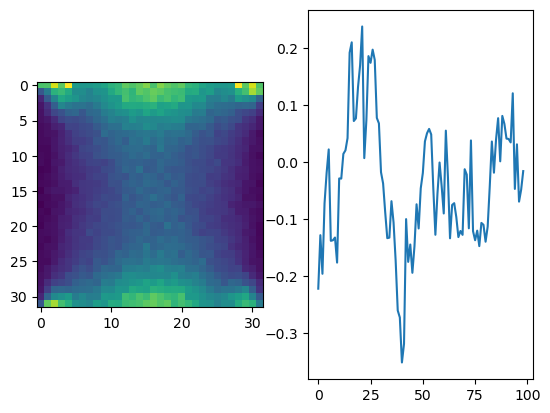

In [43]:
get_phases(x0_estimates[:-1], target_frame, x0_estimates[-1])

In [150]:
distances_freq_wise

tensor([8.9910e-06, 8.8826e-06, 8.9311e-06, 9.0581e-06, 9.1039e-06, 9.0764e-06,
        9.0454e-06, 9.0522e-06, 9.0834e-06, 9.0703e-06, 9.1484e-06, 9.1008e-06,
        9.0347e-06, 8.9728e-06, 8.8992e-06, 8.8339e-06, 8.7774e-06, 8.8039e-06,
        8.7643e-06, 8.7271e-06, 8.7810e-06, 8.8023e-06, 8.7858e-06, 8.7560e-06,
        8.7207e-06, 8.6764e-06, 8.6276e-06, 8.5728e-06, 8.5529e-06, 8.4783e-06,
        8.4089e-06, 8.3407e-06, 8.3155e-06, 8.3239e-06, 8.3189e-06, 8.3424e-06,
        8.3026e-06, 8.2004e-06, 8.0826e-06, 8.0399e-06, 8.0015e-06, 7.9691e-06,
        7.9748e-06, 7.9552e-06, 7.9528e-06, 7.8689e-06, 7.8318e-06, 7.8233e-06,
        7.7809e-06, 7.7447e-06, 7.7636e-06, 7.7078e-06, 7.6666e-06, 7.6396e-06,
        7.5485e-06, 7.4565e-06, 7.3795e-06, 7.3216e-06, 7.2843e-06, 7.2811e-06,
        7.2912e-06, 7.2241e-06, 7.0777e-06, 6.9489e-06, 6.8143e-06, 6.7416e-06,
        6.6917e-06, 6.6225e-06, 6.5517e-06, 6.4484e-06, 6.3291e-06, 6.2221e-06,
        6.1591e-06, 6.0908e-06, 5.9931e-

In [38]:
import torch

def predict_average_error(
    x,         # (T, B, C, H, W) real or complex
    Y,         # (B, C, H, W)
    Z,         # (B, C, H, W)
    device=None
):
    """
    Returns:
      c: (T, C, H, W) complex (or real if real=True) optimal coefficients
      distances: (T,) distance in image domain (MSE if reduction="mean", else sum of squared error)
      Zhat_img: (T, B, C, H, W) reconstructed images (real)
    """
    if device is None:
        device = x.device

    # ensure complex dtype for FFT math
    dtype = torch.complex64
    x_c = x.to(dtype) if not torch.is_complex(x) else x
    Y_c = Y.to(dtype) if not torch.is_complex(Y) else Y
    Z_c = Z.to(dtype) if not torch.is_complex(Z) else Z

    # FFT spatial dims
    F = torch.fft.fftn(x_c, dim=(-2, -1))    # (T, B, C, H, W)
    FY = torch.fft.fftn(Y_c, dim=(-2, -1))   # (B, C, H, W)
    Zfft = torch.fft.fftn(Z_c, dim=(-2, -1)) # (B, C, H, W)

    # Broadcast FY and Zfft over time T
    FY_tb = FY.unsqueeze(0).expand(F.shape)  # (T, B, C, H, W)
    Z_tb  = Zfft.unsqueeze(0).expand(F.shape) # (T, B, C, H, W)

    # A = F - FY, B = Z - FY (B independent of T, but expanded)
    A = F - FY_tb       # (T, B, C, H, W)
    B = Z_tb - FY_tb    # (T, B, C, H, W)

    D_z = Zfft - FY
    print(D_z.shape)
    mean_error = D_z.mean(dim=0, keepdim=True)
    print(mean_error.shape)
    print(torch.mean((torch.fft.ifftn(Zfft, dim=(-2,-1)) - torch.fft.ifftn(FY + mean_error, dim=(-2,-1)))**2))
    
    #print(torch.abs(A/torch.abs(A)))


In [39]:
predict_average_error(x0_estimates[:-1], target_frame, x0_estimates[-1])

torch.Size([256, 2, 32, 32])
torch.Size([1, 2, 32, 32])
tensor(5.7383e-05-2.5707e-12j, device='cuda:0')


In [151]:
torch.mean((x0_estimates[-1]-target_frame)**2)

tensor(1.2776e-05, device='cuda:0')

In [40]:
import torch

def linear_freq_regression_stable(X, Y, Z, reduction='mean', lambda_reg=1e-6):
    """
    Stable linear regression in frequency domain: Fhat = c1*F + c2*FY
    Solves separately for real and imaginary parts with ridge regularization.

    X: (T,B,C,H,W)
    Y: (B,C,H,W)
    Z: (B,C,H,W)

    Returns:
        Coef: (T,2,C,H,W) linear coefficients (complex)
        distances: (T,) image-domain MSE
        Zhat_img: (T,B,C,H,W) predicted images (real)
    """
    T,B,C,H,W = X.shape

    # FFT
    F = torch.fft.fftn(X, dim=(-2,-1))
    FY = torch.fft.fftn(Y, dim=(-2,-1))
    FZ = torch.fft.fftn(Z, dim=(-2,-1))

    # Prepare outputs
    Coef = torch.zeros((T,2,C,H,W), dtype=torch.complex64, device=X.device)
    Zhat_fft = torch.zeros((T,B,C,H,W), dtype=torch.complex64, device=X.device)

    I2 = torch.eye(2, device=X.device)  # for ridge regularization

    for t in range(T):
        print(t)
        if t == 2:break
        for c in range(C):
            for h in range(H):
                for w in range(W):
                    F_tw = F[t,:,c,h,w]   # (B,)
                    FY_hw = FY[:,c,h,w]   # (B,)
                    Z_hw = FZ[:,c,h,w]    # (B,)

                    # Real and Imag design matrices
                    A_real = torch.stack([F_tw.real, FY_hw.real], dim=-1)  # (B,2)
                    A_imag = torch.stack([F_tw.imag, FY_hw.imag], dim=-1)  # (B,2)
                    Z_real = Z_hw.real
                    Z_imag = Z_hw.imag

                    # Ridge linear solve: (A^T A + λ I) c = A^T b
                    AtA_real = A_real.T @ A_real + lambda_reg * I2
                    Atb_real = A_real.T @ Z_real
                    c1c2_real = torch.linalg.solve(AtA_real, Atb_real)

                    AtA_imag = A_imag.T @ A_imag + lambda_reg * I2
                    Atb_imag = A_imag.T @ Z_imag
                    c1c2_imag = torch.linalg.solve(AtA_imag, Atb_imag)

                    # Combine into complex coefficients
                    Coef[t,:,c,h,w] = torch.view_as_complex(
                        torch.stack([c1c2_real, c1c2_imag], dim=-1)
                    )

                    # Prediction
                    Zhat_fft[t,:,c,h,w] = F_tw * Coef[t,0,c,h,w] + FY_hw * Coef[t,1,c,h,w]

    # Inverse FFT to image domain
    Zhat_img = torch.fft.ifftn(Zhat_fft, dim=(-2,-1)).real

    # Image-domain squared error
    err = (Zhat_img - Z) ** 2
    if reduction == 'mean':
        distances = err.mean(dim=(1,2,3,4))
    elif reduction == 'sum':
        distances = err.sum(dim=(1,2,3,4))
    else:
        raise ValueError("reduction must be 'mean' or 'sum'")

    return Coef, distances, Zhat_img


In [41]:
import torch

def linear_freq_regression_crossfreq_blocks(X, Y, Z, block_size=1, reduction='mean', lambda_reg=1e-12):
    """
    Memory-efficient block-wise cross-frequency regression.
    Each frequency block depends only on a local block of input frequencies.
    
    X: (T,B,C,H,W)
    Y: (B,C,H,W)
    Z: (B,C,H,W)
    
    Returns:
        Coef: (T,2,C,H,W,num_predictors_per_block) complex coefficients
        distances: (T,) image-domain MSE
        Zhat_img: (T,B,C,H,W)
    """
    T,B,C,H,W = X.shape

    # FFT
    F = torch.fft.fftn(X, dim=(-2,-1))
    FY = torch.fft.fftn(Y, dim=(-2,-1))
    FZ = torch.fft.fftn(Z, dim=(-2,-1))

    # Determine max number of predictors per block
    max_predictors = 2 * block_size * block_size

    # Prepare outputs
    Coef = torch.zeros((T,2,C,H,W,max_predictors), dtype=torch.complex64, device=X.device)
    Zhat_fft = torch.zeros((T,B,C,H,W), dtype=torch.complex64, device=X.device)

    for t in range(T):
        print(f"Processing t={t}")
        #if t == 2: break  # for testing
        for c in range(C):
            for hh in range(0,H,block_size):
                for ww in range(0,W,block_size):
                    # Target block
                    h_block = slice(hh, min(hh+block_size,H))
                    w_block = slice(ww, min(ww+block_size,W))
                    block_h = h_block.stop - h_block.start
                    block_w = w_block.stop - w_block.start

                    # Flatten target block
                    Z_block = FZ[:,c,h_block,w_block].reshape(B, -1)  # (B, block_h*block_w)

                    # Input blocks (flattened)
                    F_block = F[t,:,c,h_block,w_block].reshape(B, -1)
                    FY_block = FY[:,c,h_block,w_block].reshape(B, -1)

                    # Design matrices
                    A_real = torch.cat([F_block.real, FY_block.real], dim=-1)  # (B, 2*block_h*block_w)
                    A_imag = torch.cat([F_block.imag, FY_block.imag], dim=-1)
                    Z_real = Z_block.real
                    Z_imag = Z_block.imag

                    # Flattened number of targets and predictors
                    num_targets = block_h * block_w
                    num_predictors = 2 * num_targets  # F + FY

                    # Solve ridge for real and imaginary parts
                    I = torch.eye(num_predictors, device=X.device) * lambda_reg
                    c_real = torch.linalg.solve(A_real.T @ A_real + I, A_real.T @ Z_real)  # (num_predictors, num_targets)
                    c_imag = torch.linalg.solve(A_imag.T @ A_imag + I, A_imag.T @ Z_imag)

                    # Combine into complex coefficients: shape (num_predictors, num_targets)
                    c_complex = torch.view_as_complex(torch.stack([c_real, c_imag], dim=-1))

                    # Prediction
                    F_block_flat = F[t,:,c,h_block,w_block].reshape(B, -1)
                    FY_block_flat = FY[:,c,h_block,w_block].reshape(B, -1)
                    Zhat_block = F_block_flat @ c_complex[:num_targets, :] + FY_block_flat @ c_complex[num_targets:, :]
                    Zhat_fft[t,:,c,h_block,w_block] = Zhat_block.reshape(B, block_h, block_w)

    # Inverse FFT to image domain
    Zhat_img = torch.fft.ifftn(Zhat_fft, dim=(-2,-1)).real

    # Image-domain squared error
    err = (Zhat_img - Z) ** 2
    if reduction=='mean':
        distances = err.mean(dim=(1,2,3,4))
    elif reduction=='sum':
        distances = err.sum(dim=(1,2,3,4))
    else:
        raise ValueError("reduction must be 'mean' or 'sum'")

    return Coef, distances, Zhat_img


In [42]:
import torch

def linear_freq_regression_cg_blocks(X, Y, Z, block_size=8, lambda_reg=1e-12, max_iter=50, tol=1e-8):
    """
    Block-wise linear regression with conjugate gradient, fully complex, memory-efficient.
    
    X: (T,B,C,H,W)
    Y: (B,C,H,W)
    Z: (B,C,H,W)
    """
    T,B,C,H,W = X.shape

    F = torch.fft.fftn(X, dim=(-2,-1))
    FY = torch.fft.fftn(Y, dim=(-2,-1))
    FZ = torch.fft.fftn(Z, dim=(-2,-1))

    Zhat_fft = torch.zeros_like(F)
    
    for t in range(T):
        print(f"Processing t={t}")
        if t == 1: break
        for c in range(C):
            for hh in range(0,H,block_size):
                for ww in range(0,W,block_size):
                    h_block = slice(hh, min(hh+block_size,H))
                    w_block = slice(ww, min(ww+block_size,W))
                    block_h = h_block.stop - h_block.start
                    block_w = w_block.stop - w_block.start
                    num_targets = block_h * block_w
                    num_predictors = 2 * num_targets  # F + FY

                    # Flatten input and target blocks
                    F_block = F[t,:,c,h_block,w_block].reshape(B, -1)  # (B, block_h*block_w)
                    FY_block = FY[:,c,h_block,w_block].reshape(B, -1)
                    Z_block = FZ[:,c,h_block,w_block].reshape(B, -1)  # (B, num_targets)

                    # Concatenate inputs: (B, 2*num_targets)
                    A_block = torch.cat([F_block, FY_block], dim=1)

                    # Solve for all targets in the block simultaneously using CG
                    # x: (2*num_targets, num_targets) coefficient matrix
                    x = torch.zeros((num_predictors, num_targets), dtype=torch.complex64, device=X.device)

                    # Precompute A^T b for all targets
                    Atb = A_block.conj().T @ Z_block  # (num_predictors, num_targets)

                    # Initialize residuals r = Atb - (A^T A + λ I) x0, x0=0 → r = Atb
                    r = Atb.clone()
                    p = r.clone()
                    rsold = torch.sum(r.real**2, dim=0)  # (num_targets,)

                    eps = 1e-12
                    for i in range(max_iter):
                        Ap = A_block.conj().T @ (A_block @ p) + lambda_reg * p
                        denom = torch.sum(p.conj() * Ap, dim=0).real + eps
                        alpha = rsold / denom
                        x += alpha.unsqueeze(0) * p
                        r -= alpha.unsqueeze(0) * Ap
                        rsnew = torch.sum(r.conj() * r, dim=0).real
                        if torch.all(rsnew < tol):
                            break
                        beta = rsnew / (rsold + eps)
                        p = r + beta.unsqueeze(0) * p
                        rsold = rsnew

                    # Prediction for the block
                    Zhat_block = A_block @ x  # (B, num_targets)
                    print(x.shape, A_block.shape)
                    Zhat_fft[t,:,c,h_block,w_block] = Zhat_block.reshape(B, block_h, block_w)

    print(torch.sum(torch.isnan(Zhat_fft)))
    print(A_block.shape)
    
    # Back to image domain
    Zhat_img = torch.fft.ifftn(Zhat_fft, dim=(-2,-1)).real
    print(Zhat_img[0,0,0])
    distances = ((Zhat_img - Z)**2).mean(dim=(1,2,3,4))
    return distances, Zhat_img


In [43]:
distances, Zhat_img = linear_freq_regression_cg_blocks(x0_estimates[:-1], target_frame, x0_estimates[-1], block_size=1)

Processing t=0
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.Size([256, 2])
torch.Size([2, 1]) torch.

In [44]:
distances

tensor([5.4303e-05, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01, 8.7181e-01,
        8.7181e-01, 8.7181e-01, 8.7181e-

In [48]:
Coef, distances, Zhat_img = linear_freq_regression_crossfreq_blocks(x0_estimates[:-1], target_frame, x0_estimates[-1], block_size=16)

Processing t=0
Processing t=1
Processing t=2
Processing t=3
Processing t=4
Processing t=5
Processing t=6
Processing t=7
Processing t=8
Processing t=9
Processing t=10
Processing t=11
Processing t=12
Processing t=13
Processing t=14
Processing t=15
Processing t=16
Processing t=17
Processing t=18
Processing t=19
Processing t=20
Processing t=21
Processing t=22
Processing t=23
Processing t=24
Processing t=25
Processing t=26
Processing t=27
Processing t=28
Processing t=29
Processing t=30
Processing t=31
Processing t=32
Processing t=33
Processing t=34
Processing t=35
Processing t=36
Processing t=37
Processing t=38
Processing t=39
Processing t=40
Processing t=41
Processing t=42
Processing t=43
Processing t=44
Processing t=45
Processing t=46
Processing t=47
Processing t=48
Processing t=49
Processing t=50
Processing t=51
Processing t=52
Processing t=53
Processing t=54
Processing t=55
Processing t=56
Processing t=57
Processing t=58
Processing t=59
Processing t=60
Processing t=61
Processing t=62
Pr

In [106]:
distances

tensor([1.0514e-05, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00, 1.0269e+00,
        1.0269e+00, 1.0269e+00, 1.0269e+

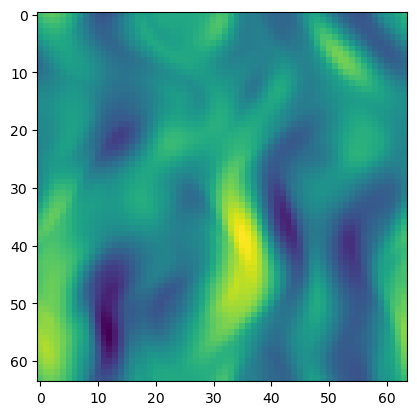

In [71]:
plt.imshow(estimated_combinations[0,0,0].cpu())

In [33]:
distances_estimates = [torch.mean((estimate - x0_estimates[-1])**2).cpu() for estimate in x0_estimates[:-1]]

In [34]:
distances_freq_wise

NameError: name 'distances_freq_wise' is not defined

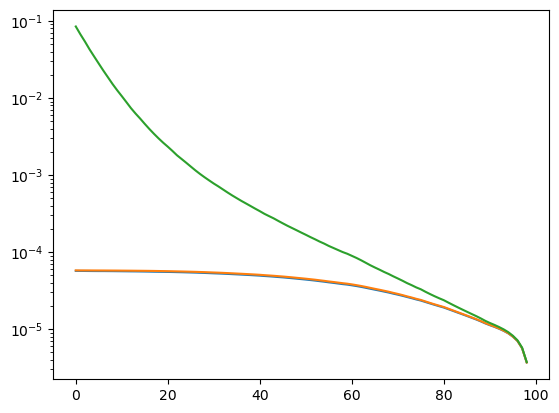

In [25]:
plt.plot(distances_freq_wise.cpu())
plt.plot(distances_image_wise.cpu())
plt.plot([torch.mean((estimate - x0_estimates[-1])**2).cpu() for estimate in x0_estimates[:-1]])
#plt.plot([torch.mean((x0_estimates[-1] - target_frame)**2).cpu() for i in range(99)])
plt.yscale('log')

In [18]:
import torch

def optimal_img_mix_and_distances(
    x,   # (T,B,C,H,W)
    Y,   # (B,C,H,W)
    Z,   # (B,C,H,W)
    eps=1e-12,
    clamp01=False,
    reduction="mean"
):
    """
    Fit per-(t,c,h,w) coefficient c that linearly mixes x[t,:,c,h,w] and Y[:,c,h,w]
    to approximate Z[:,c,h,w] in image domain.

    Returns:
      c: (T,C,H,W) real coefficients
      distances: (T,) distance in image domain (MSE or sum)
      Zhat_img: (T,B,C,H,W) reconstructed image
    """

    # Expand Y,Z to (T,B,C,H,W)
    Y_tb = Y.unsqueeze(0).expand(x.shape)
    Z_tb = Z.unsqueeze(0).expand(x.shape)

    # A = x - Y, B = Z - Y
    A = x - Y_tb         # (T,B,C,H,W)
    B = Z_tb - Y_tb      # (T,B,C,H,W)

    # numerator and denominator across batch B only
    num = torch.sum(A * B, dim=1)             # (T,C,H,W)
    denom = torch.sum(A * A, dim=1)           # (T,C,H,W)

    # optimal coefficient
    c = num / (denom + eps)                   # (T,C,H,W)
    if clamp01:
        c = c.clamp(0.0, 1.0)

    # reconstruct
    Zhat_img = c.unsqueeze(1) * x + (1.0 - c.unsqueeze(1)) * Y_tb  # (T,B,C,H,W)

    # error vs true Z
    err = (Zhat_img - Z_tb) ** 2              # (T,B,C,H,W)
    if reduction == "mean":
        distances = err.mean(dim=(1,2,3,4))   # (T,)
    elif reduction == "sum":
        distances = err.sum(dim=(1,2,3,4))    # (T,)
    else:
        raise ValueError("reduction must be 'mean' or 'sum'")

    return c, distances, Zhat_img


In [19]:
c, distances_image_wise, estimated_combinations = optimal_img_mix_and_distances(x0_estimates[:-1], target_frame, x0_estimates[-1])

In [20]:
distances_image_wise

tensor([5.7948e-05, 5.7877e-05, 5.7862e-05, 5.7845e-05, 5.7804e-05, 5.7774e-05,
        5.7739e-05, 5.7692e-05, 5.7657e-05, 5.7604e-05, 5.7532e-05, 5.7473e-05,
        5.7405e-05, 5.7328e-05, 5.7256e-05, 5.7187e-05, 5.7095e-05, 5.6976e-05,
        5.6849e-05, 5.6709e-05, 5.6556e-05, 5.6407e-05, 5.6231e-05, 5.6069e-05,
        5.5869e-05, 5.5672e-05, 5.5467e-05, 5.5213e-05, 5.4959e-05, 5.4674e-05,
        5.4378e-05, 5.4111e-05, 5.3800e-05, 5.3443e-05, 5.3088e-05, 5.2720e-05,
        5.2351e-05, 5.1976e-05, 5.1592e-05, 5.1201e-05, 5.0769e-05, 5.0236e-05,
        4.9772e-05, 4.9299e-05, 4.8760e-05, 4.8248e-05, 4.7655e-05, 4.7054e-05,
        4.6406e-05, 4.5803e-05, 4.5176e-05, 4.4513e-05, 4.3853e-05, 4.3094e-05,
        4.2392e-05, 4.1594e-05, 4.0942e-05, 4.0228e-05, 3.9517e-05, 3.8924e-05,
        3.8122e-05, 3.7269e-05, 3.6367e-05, 3.5398e-05, 3.4365e-05, 3.3395e-05,
        3.2485e-05, 3.1546e-05, 3.0630e-05, 2.9597e-05, 2.8675e-05, 2.7699e-05,
        2.6663e-05, 2.5751e-05, 2.4764e-

tensor([8.4755e-02, 6.7042e-02, 5.3877e-02, 4.2698e-02, 3.4476e-02, 2.7917e-02,
        2.2636e-02, 1.8525e-02, 1.5159e-02, 1.2590e-02, 1.0570e-02, 8.8366e-03,
        7.3728e-03, 6.2726e-03, 5.3994e-03, 4.6069e-03, 3.9564e-03, 3.4254e-03,
        2.9884e-03, 2.6275e-03, 2.3323e-03, 2.0577e-03, 1.8043e-03, 1.6153e-03,
        1.4444e-03, 1.2879e-03, 1.1498e-03, 1.0336e-03, 9.3550e-04, 8.5085e-04,
        7.7530e-04, 7.1157e-04, 6.4979e-04, 5.9334e-04, 5.4376e-04, 5.0077e-04,
        4.6161e-04, 4.2769e-04, 3.9594e-04, 3.6626e-04, 3.3977e-04, 3.1390e-04,
        2.9321e-04, 2.7432e-04, 2.5421e-04, 2.3617e-04, 2.1974e-04, 2.0551e-04,
        1.9211e-04, 1.7935e-04, 1.6781e-04, 1.5659e-04, 1.4672e-04, 1.3701e-04,
        1.2881e-04, 1.2015e-04, 1.1312e-04, 1.0644e-04, 1.0021e-04, 9.5232e-05,
        8.9475e-05, 8.4042e-05, 7.8440e-05, 7.2852e-05, 6.7609e-05, 6.3181e-05,
        5.9227e-05, 5.5310e-05, 5.2005e-05, 4.8523e-05, 4.5478e-05, 4.2540e-05,
        3.9615e-05, 3.7239e-05, 3.4823e-

In [108]:
import torch

def optimal_img_mix_per_channel(
    x,   # (T,B,C,H,W)
    Y,   # (B,C,H,W)
    Z,   # (B,C,H,W)
    eps=1e-12,
    clamp01=False,
    reduction="mean"
):
    """
    Fit per-(t,c) coefficient c that linearly mixes x[t,:,c,:,:] and Y[:,c,:,:]
    to approximate Z[:,c,:,:] in image domain.

    Returns:
      c: (T,C) real coefficients
      distances: (T,) distance in image domain (MSE or sum)
      Zhat_img: (T,B,C,H,W) reconstructed images
    """

    # Expand Y,Z to (T,B,C,H,W)
    Y_tb = Y.unsqueeze(0).expand(x.shape)
    Z_tb = Z.unsqueeze(0).expand(x.shape)

    # A = x - Y, B = Z - Y
    A = x - Y_tb   # (T,B,C,H,W)
    B = Z_tb - Y_tb

    # numerator and denominator, summed over (B,H,W)
    num = torch.sum(A * B, dim=(1,3,4))     # (T,C)
    denom = torch.sum(A * A, dim=(1,3,4))   # (T,C)

    c = num / (denom + eps)                 # (T,C)
    if clamp01:
        c = c.clamp(0.0, 1.0)

    # reconstruct Zhat
    c_exp = c[:, None, :, None, None]       # (T,1,C,1,1)
    Zhat_img = c_exp * x + (1.0 - c_exp) * Y_tb  # (T,B,C,H,W)

    # error in image domain
    err = (Zhat_img - Z_tb) ** 2
    if reduction == "mean":
        distances = err.mean(dim=(1,2,3,4))  # (T,)
    elif reduction == "sum":
        distances = err.sum(dim=(1,2,3,4))   # (T,)
    else:
        raise ValueError("reduction must be 'mean' or 'sum'")

    return c, distances, Zhat_img


In [109]:
c, distances_image_wise, estimated_combinations = optimal_img_mix_per_channel(x0_estimates[:-1], target_frame, x0_estimates[-1])

In [22]:
c

tensor([[9.4064e-03, 1.2207e-03],
        [1.0763e-02, 1.3126e-03],
        [1.2153e-02, 1.3278e-03],
        [1.3397e-02, 1.3300e-03],
        [1.5056e-02, 1.3824e-03],
        [1.6600e-02, 1.0848e-03],
        [1.7934e-02, 9.4790e-04],
        [2.0285e-02, 8.5363e-04],
        [2.2287e-02, 8.8923e-04],
        [2.4545e-02, 1.0784e-03],
        [2.6583e-02, 9.9869e-04],
        [2.9375e-02, 1.2689e-03],
        [3.2840e-02, 1.7019e-03],
        [3.4991e-02, 2.5047e-03],
        [3.8697e-02, 3.4271e-03],
        [4.2271e-02, 4.2173e-03],
        [4.5743e-02, 4.9757e-03],
        [4.8381e-02, 5.6405e-03],
        [5.2793e-02, 6.9105e-03],
        [5.6293e-02, 7.3526e-03],
        [5.9536e-02, 6.8297e-03],
        [6.4409e-02, 7.3252e-03],
        [6.8709e-02, 8.6728e-03],
        [7.3199e-02, 1.1059e-02],
        [7.7047e-02, 1.1910e-02],
        [8.2794e-02, 1.4956e-02],
        [8.8237e-02, 1.7720e-02],
        [9.1663e-02, 1.8915e-02],
        [9.6296e-02, 2.1630e-02],
        [1.027

### Physical residual for conditional Diffusion Models

In [30]:
import torch
import math

def divergence_loss_spectral(u, dx=1.0, dy=1.0, lambda_div=1.0, reduction='mean'):
    """
    Spectral L2 divergence loss.

    u: tensor shape (B, 2, H, W) -- velocity (u_x, u_y) in real space (float)
    dx, dy: grid spacing (scalars)
    lambda_div: multiplier for the divergence loss
    reduction: 'mean' or 'sum' over batch+space

    Returns scalar loss (torch scalar).
    """
    B, C, H, W = u.shape
    assert C == 2, "u must have shape (B,2,H,W)"

    # FFT of velocity field
    u_hat = torch.fft.fftn(u, dim=(-2, -1))  # complex tensor shape (B,2,H,W)

    # angular wavenumbers: k = 2*pi*freq
    kx_1d = 2.0 * math.pi * torch.fft.fftfreq(H, d=dx, device=u.device, dtype=u.dtype)  # (H,)
    ky_1d = 2.0 * math.pi * torch.fft.fftfreq(W, d=dy, device=u.device, dtype=u.dtype)  # (W,)

    kx = kx_1d.view(H, 1)    # (H,1)
    ky = ky_1d.view(1, W)    # (1,W)

    # compute i*(kx * u_hat_x + ky * u_hat_y)
    # broadcasting: u_hat[:, 0, :, :] has shape (B,H,W)
    ik = 1j
    div_hat = ik * (kx * u_hat[:, 0, :, :] + ky * u_hat[:, 1, :, :])  # (B,H,W) complex

    # spectral divergence energy: sum |div_hat|^2
    # optionally normalize by number of modes (H*W)
    div_energy = (div_hat.real**2 + div_hat.imag**2)  # (B,H,W) real

    plt.imshow(div_energy[0].cpu())

    if reduction == 'mean':
        loss = lambda_div * div_energy.mean()
    elif reduction == 'sum':
        loss = lambda_div * div_energy.sum()
    else:
        raise ValueError("reduction must be 'mean' or 'sum'")

    return loss


def compute_vorticity(u):
    """
    Compute 2D vorticity from velocity field.

    u: (B, 2, H, W)  velocity field
       u[:,0] = u_x, u[:,1] = u_y

    Returns:
        omega: (B, H, W) vorticity
    """
    u_x = u[:, 0]
    u_y = u[:, 1]

    # periodic finite differences
    dvdx = u_y[..., 1:] - u_y[..., :-1]
    dvdx = torch.cat([dvdx, u_y[..., :1] - u_y[..., -1:]], dim=-1)

    dudy = u_x[..., 1:, :] - u_x[..., :-1, :]
    dudy = torch.cat([dudy, u_x[..., :1, :] - u_x[..., -1:, :]], dim=-2)

    omega = dvdx - dudy
    return omega


class EnstrophyConservationLoss(nn.Module):
    def __init__(self, reduction="mean"):
        super().__init__()
        self.reduction = reduction

    def forward(self, u_pred, u_true):
        """
        u_pred, u_true: (B, 2, H, W) velocity fields
        """
        omega_pred = compute_vorticity(u_pred)
        omega_true = compute_vorticity(u_true)

        # enstrophy density
        ens_pred = 0.5 * (omega_pred**2).mean(dim=(-2, -1))  # (B,)
        ens_true = 0.5 * (omega_true**2).mean(dim=(-2, -1))  # (B,)

        loss = (ens_pred - ens_true).pow(2)  # (B,)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

tensor(3.0727, device='cuda:0')

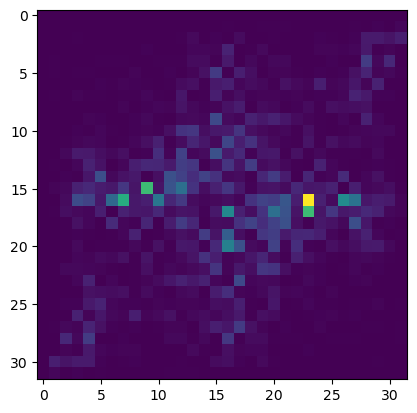

In [31]:
divergence_loss_spectral(x0_estimates[-1])

tensor(3.2383, device='cuda:0')

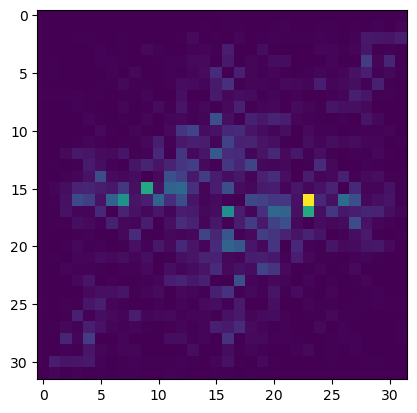

In [32]:
divergence_loss_spectral(target_frame)

In [24]:
print([divergence_loss_spectral(ta) for est in estimated_combinations])

NameError: name 'estimated_combinations' is not defined

In [170]:
divergence_loss_spectral(target_frame)

tensor(0.6450, device='cuda:0')

In [172]:
EnstrophyConservationLoss()(target_frame, x0_estimates[-1])

tensor(9.7292e-09, device='cuda:0')

### How diverse are Diffusion Models's predictions ? 

In [68]:
model.eval()

statistics_eval_mode = {}

with torch.no_grad():
    for batch_idx, sample in enumerate(val_loader):
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        

        prediction1, _ = model(conditioning_frame, require_x0_estimate = True)
        prediction2, _ = model(conditioning_frame, require_x0_estimate = True)
        prediction3, _ = model(conditioning_frame, require_x0_estimate = True)
        if batch_idx ==1 : break

In [69]:
torch.mean((prediction1 - prediction2)**2), torch.mean((prediction1 - prediction3)**2), torch.mean((prediction2 - prediction3)**2)

(tensor(5.3599e-06, device='cuda:0'),
 tensor(5.9843e-06, device='cuda:0'),
 tensor(6.2800e-06, device='cuda:0'))

In [70]:
torch.mean((prediction1 - target_frame)**2), torch.mean((prediction2 - target_frame)**2), torch.mean((prediction3 - target_frame)**2)

(tensor(1.3820e-05, device='cuda:0'),
 tensor(1.3259e-05, device='cuda:0'),
 tensor(1.3252e-05, device='cuda:0'))

In [78]:
import random
from src.utils import separateFrequencies
chain = KolmogorovFlow(size=256, dt=0.2)

dt_chain = KolmogorovFlow(size=256, dt=0.05)

random.seed(2)
x = chain.prior()

y = chain.trajectory(x, length=30)

y_noised_start = dt_chain.trajectory(x, length=1)[0]

y_mixed = mix_high_frequencies(x, y_noised_start, alpha=0.9)

print(torch.mean((y_noised_start - x)**2))
print(torch.mean((KolmogorovFlow.coarsen(y_noised_start, 8) - KolmogorovFlow.coarsen(x, 8))**2))
print(torch.mean((y_mixed - x)**2))
print(torch.mean((KolmogorovFlow.coarsen(y_mixed, 8) - KolmogorovFlow.coarsen(x, 8))**2))


x_lf, x_hf = separateFrequencies(x, cutoff_frequency=150)
y_lf, y_hf = separateFrequencies(y[0], cutoff_frequency=150)

y_noised = chain.trajectory(y_mixed, length=30)

#y_noised = chain.trajectory(x_lf[0] + y_hf[0], length=30)

#y_noised = chain.trajectory(x + separateFrequencies(torch.randn_like(x), cutoff_frequency=150)[1][0]*0.001, length=30)

tensor(0.0060)
tensor(0.0051)
tensor(4.8106e-07)
tensor(9.7976e-09)


In [79]:
print([(i, torch.mean((y[i] - y_noised[i])**2)) for i in range(len(y))])

[(0, tensor(1.0252e-07)), (1, tensor(6.6746e-08)), (2, tensor(5.5677e-08)), (3, tensor(5.0598e-08)), (4, tensor(4.6041e-08)), (5, tensor(4.4132e-08)), (6, tensor(4.6637e-08)), (7, tensor(5.5252e-08)), (8, tensor(7.3435e-08)), (9, tensor(1.0397e-07)), (10, tensor(1.5080e-07)), (11, tensor(2.1216e-07)), (12, tensor(2.7337e-07)), (13, tensor(3.3366e-07)), (14, tensor(4.1298e-07)), (15, tensor(5.4566e-07)), (16, tensor(7.9552e-07)), (17, tensor(1.1610e-06)), (18, tensor(1.5510e-06)), (19, tensor(1.9811e-06)), (20, tensor(2.5265e-06)), (21, tensor(3.2026e-06)), (22, tensor(3.9981e-06)), (23, tensor(4.9839e-06)), (24, tensor(6.5095e-06)), (25, tensor(9.0842e-06)), (26, tensor(1.3127e-05)), (27, tensor(1.8921e-05)), (28, tensor(2.6744e-05)), (29, tensor(3.5976e-05))]


In [8]:
print([(i, torch.mean((KolmogorovFlow.coarsen(y[i], 8) - KolmogorovFlow.coarsen(y_noised[i], 8))**2)) for i in range(len(y))])

[(0, tensor(1.0260e-14)), (1, tensor(1.3939e-14)), (2, tensor(1.8581e-14)), (3, tensor(2.1064e-14)), (4, tensor(2.5616e-14)), (5, tensor(3.2907e-14)), (6, tensor(4.1602e-14)), (7, tensor(5.5152e-14)), (8, tensor(7.6102e-14)), (9, tensor(9.8562e-14)), (10, tensor(1.2665e-13)), (11, tensor(1.6704e-13)), (12, tensor(2.1803e-13)), (13, tensor(3.0471e-13)), (14, tensor(4.5882e-13)), (15, tensor(7.0638e-13)), (16, tensor(1.1248e-12)), (17, tensor(1.7943e-12)), (18, tensor(2.5513e-12)), (19, tensor(3.2439e-12)), (20, tensor(4.1211e-12)), (21, tensor(5.3453e-12)), (22, tensor(7.3787e-12)), (23, tensor(1.0376e-11)), (24, tensor(1.4305e-11)), (25, tensor(2.0134e-11)), (26, tensor(2.9336e-11)), (27, tensor(4.2405e-11)), (28, tensor(5.7136e-11)), (29, tensor(7.2732e-11))]


torch.Size([1, 2, 256, 256])


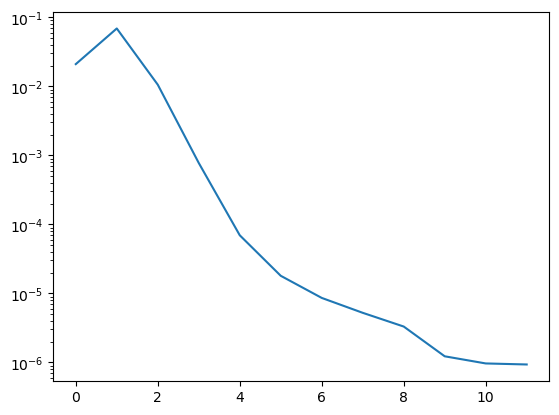

In [35]:
from src.utils import compute_radial_psd_error

plt.plot(compute_radial_psd_error(y[0].unsqueeze(0), y_noised[0].unsqueeze(0)).values())
noise = torch.randn_like(x).unsqueeze(0)
print(noise.shape)
#plt.plot(compute_radial_psd_error(separateFrequencies(noise, cutoff_frequency=128)[1], torch.zeros(noise.shape)).values())
plt.yscale('log')

torch.Size([47023])
torch.Size([47023])
torch.Size([1, 2, 256, 256])


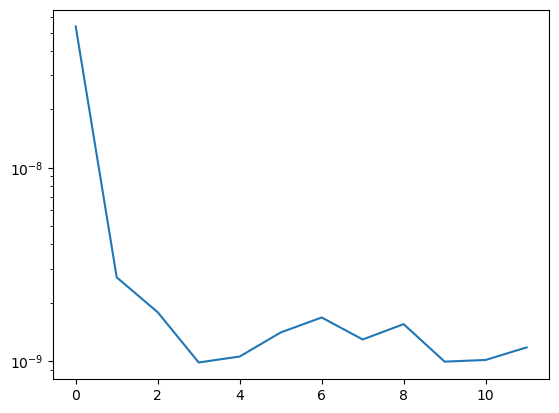

In [38]:
x_lf[0] + y_hf[0]

from src.utils import compute_radial_psd_error

plt.plot(compute_radial_psd_error((phase_shuffle_high_freq(x, freq_thresh=0.3)).unsqueeze(0), x.unsqueeze(0)).values())
noise = torch.randn_like(x).unsqueeze(0)
print(noise.shape)
#plt.plot(compute_radial_psd_error(separateFrequencies(noise, cutoff_frequency=128)[1], torch.zeros(noise.shape)).values())
plt.yscale('log')

In [53]:
def phase_shuffle_high_freq(img: torch.Tensor, freq_thresh: float) -> torch.Tensor:
    """
    Shuffle phase of a torch image in Fourier space above a frequency threshold.

    Args:
        img: torch.Tensor of shape (C, H, W), real-valued image
        freq_thresh: float in [0, 0.5], frequency radius threshold (0.5 = Nyquist)

    Returns:
        img_out: torch.Tensor of shape (C, H, W)
    """
    C, H, W = img.shape
    assert H == W, "Only square images supported for simplicity"

    # FFT
    fft = torch.fft.fft2(img, dim=(-2, -1))
    mag = torch.abs(fft)
    phase = torch.angle(fft)

    # frequency grid
    fy = torch.fft.fftfreq(H, device=img.device)
    fx = torch.fft.fftfreq(W, device=img.device)
    FX, FY = torch.meshgrid(fx, fy, indexing="xy")
    freq_radius = torch.sqrt(FX**2 + FY**2)

    # High-frequency mask
    high_mask = freq_radius >= freq_thresh

    # New phase (copy original first)
    new_phase = phase.clone()

    for c in range(C):
        # Extract high-freq phases
        high_phase = phase[c][high_mask]
        print(high_phase.shape)
        # Permute them
        perm = torch.randperm(high_phase.numel(), device=img.device)
        shuffled = high_phase[perm]

        # Put back
        new_phase[c][high_mask] = shuffled

    # Recombine magnitude + shuffled phase
    fft_new = mag * torch.exp(1j * new_phase)
    img_out = torch.fft.ifft2(fft_new, dim=(-2, -1)).real
    return img_out

import torch

def radial_psd(img: torch.Tensor):
    """
    Compute the radially averaged Power Spectral Density (PSD) of a 2D image.

    Args:
        img: torch.Tensor of shape (C, H, W), real-valued image

    Returns:
        freqs: torch.Tensor of shape (H//2,), frequency bins in [0, 0.5]
        psd_radial: torch.Tensor of shape (C, H//2), radial PSD per channel
    """
    C, H, W = img.shape
    assert H == W, "Only square images supported for simplicity"

    # FFT and power spectrum
    fft = torch.fft.fft2(img, dim=(-2, -1))
    psd2d = torch.abs(fft) ** 2 / (H * W)

    # Frequency grid
    fy = torch.fft.fftfreq(H, device=img.device)
    fx = torch.fft.fftfreq(W, device=img.device)
    FX, FY = torch.meshgrid(fx, fy, indexing="xy")
    freq_radius = torch.sqrt(FX**2 + FY**2)

    # Flatten
    freq_radius = freq_radius.flatten()
    psd2d = psd2d.view(C, -1)

    # Bin edges (0..Nyquist)
    max_r = H // 2
    freqs = torch.linspace(0, 0.5, steps=max_r, device=img.device)

    psd_radial = torch.zeros((C, max_r), device=img.device)
    for i in range(max_r - 1):
        mask = (freq_radius >= freqs[i]) & (freq_radius < freqs[i+1])
        if mask.any():
            psd_radial[:, i] = psd2d[:, mask].mean(dim=1)

    return freqs, psd_radial

def mix_high_frequencies(x: torch.Tensor, y: torch.Tensor, freq_thresh: float = 0.1, alpha: float = 0.5):
    """
    Replace high frequencies of x with a linear combination of high frequencies from x and y.

    Args:
        x, y: torch.Tensor of shape (C, H, W)
        freq_thresh: float in [0, 0.5], cutoff for high frequencies (normalized radius)
        alpha: weight for mixing, high_freq = (1 - alpha) * Fx + alpha * Fy

    Returns:
        mixed: torch.Tensor of shape (C, H, W)
    """
    C, H, W = x.shape
    assert x.shape == y.shape, "x and y must have same shape"
    assert H == W, "Only square images supported for simplicity"

    # FFT
    Fx = torch.fft.fft2(x, dim=(-2, -1))
    Fy = torch.fft.fft2(y, dim=(-2, -1))

    # Frequency grid
    fy = torch.fft.fftfreq(H, device=x.device)
    fx = torch.fft.fftfreq(W, device=x.device)
    FX, FY = torch.meshgrid(fx, fy, indexing="xy")
    freq_radius = torch.sqrt(FX**2 + FY**2)

    # Masks
    high_mask = freq_radius >= freq_thresh

    # Mix high frequencies
    Fx_new = Fx.clone()
    Fx_new[:, high_mask] = (1 - alpha) * Fx[:, high_mask] + alpha * Fy[:, high_mask]

    # Inverse FFT
    mixed = torch.fft.ifft2(Fx_new, dim=(-2, -1)).real
    return mixed


In [25]:
print(x.shape)

torch.Size([2, 256, 256])


In [60]:
print(torch.mean((x - phase_shuffle_high_freq(x, freq_thresh=0.1))**2))

torch.Size([63475])
torch.Size([63475])
tensor(8.4181e-08)


torch.Size([65027])
torch.Size([65027])


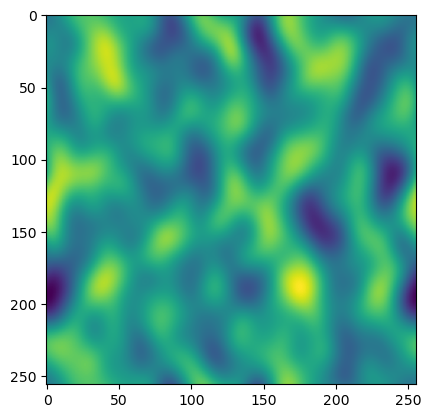

In [42]:
plt.imshow(phase_shuffle_high_freq(x, freq_thresh=0.05)[0])

torch.Size([63475])
torch.Size([63475])


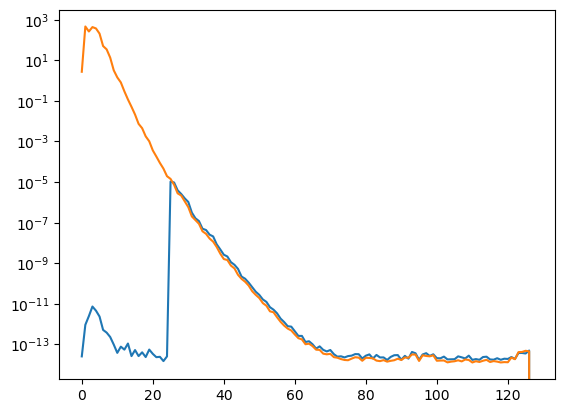

In [59]:
plt.plot(radial_psd(x - phase_shuffle_high_freq(x, freq_thresh=0.1))[1][0])
plt.plot(radial_psd(x)[1][0])

plt.yscale("log")

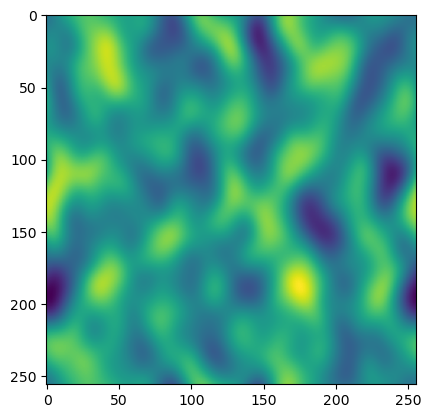

In [17]:
plt.imshow(x[0])

### Experiments on difference between train and eval predictions

In [4]:
model.train()

statistics_train_mode = {}

with torch.no_grad():
    for batch_idx, sample in enumerate(val_loader):
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        

        noise, predicted_noise, x0_estimate = model(conditioning_frame, target_frame, require_x0_estimate=True)
        if batch_idx == 1: break

statistics_train_mode['data'] = data.cpu()
statistics_train_mode['conditioning_frame'] = conditioning_frame.cpu()
statistics_train_mode['target_frame'] = target_frame.cpu()
statistics_train_mode['x0_estimate'] = x0_estimate.cpu()

NameError: name 'model' is not defined

In [63]:
noise = noise.detach().cpu()
predicted_noise = predicted_noise.detach().cpu()
x0_estimate = x0_estimate.detach().cpu()
conditioning_frame = conditioning_frame.detach().cpu()
target_frame = target_frame.detach().cpu()

In [61]:
torch.mean((predicted_noise - target_frame)**2)

tensor(1.9972e-05)

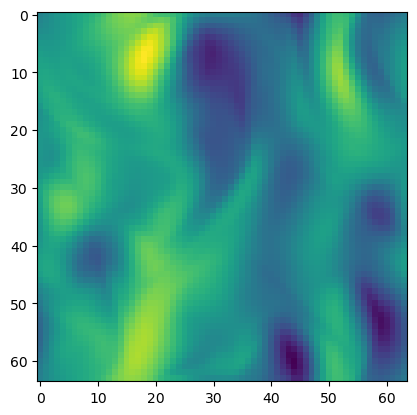

In [53]:
plt.imshow(conditioning_frame[0,0])

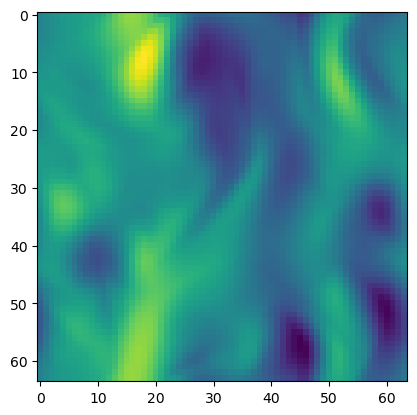

In [54]:
plt.imshow(target_frame[0,0])

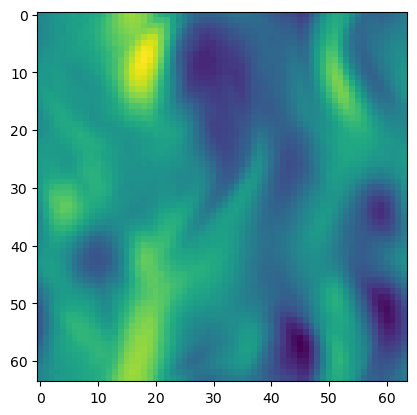

In [55]:
plt.imshow(x0_estimate[0,0])

In [57]:
torch.mean((target_frame[0,0] - x0_estimate[0,0])**2)

tensor(0.0013)

In [5]:
model.eval()

statistics_eval_mode = {}

with torch.no_grad():
    for batch_idx, sample in enumerate(val_loader):
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]
        

        prediction, all_x0_estimates = model(conditioning_frame, require_x0_estimate = True)
        if batch_idx ==1 : break

statistics_eval_mode['data'] = data.cpu()
statistics_eval_mode['conditioning_frame'] = conditioning_frame.cpu()
statistics_eval_mode['target_frame'] = target_frame.cpu()
statistics_eval_mode['prediction'] = prediction.cpu()
statistics_eval_mode['all_x0_estimates'] = all_x0_estimates.cpu()

In [7]:
torch.mean((statistics_eval_mode['prediction'] - statistics_eval_mode['target_frame'])**2)

tensor(1.3920e-05)

In [9]:
torch.mean((statistics_eval_mode['target_frame'] - statistics_train_mode['x0_estimate'])**2)

tensor(0.0027, device='cuda:0')

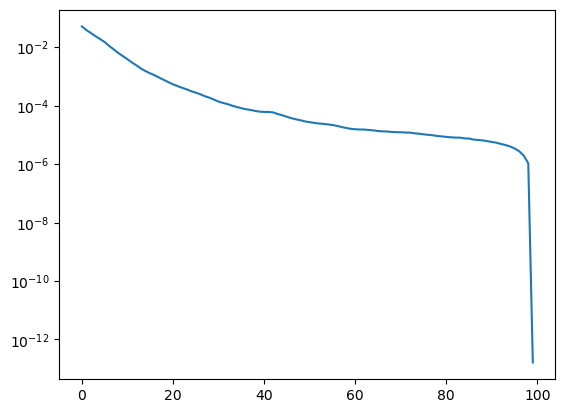

In [31]:
plt.plot([torch.mean((statistics_eval_mode['all_x0_estimates'][t] - statistics_eval_mode['prediction'])**2) for t in range(100)])
plt.yscale('log')

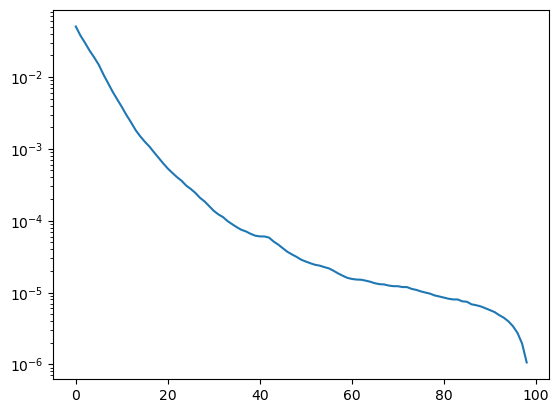

In [23]:
plt.plot([torch.mean((statistics_eval_mode['all_x0_estimates'][t] - statistics_eval_mode['prediction'])**2) for t in range(99)])
plt.yscale('log')

In [14]:
torch.mean((statistics_eval_mode['all_x0_estimates'] - statistics_eval_mode['prediction'])**2)

tensor(0.0039)

In [24]:
torch.mean((statistics_eval_mode['all_x0_estimates'] - statistics_eval_mode['prediction'])**2)

tensor(0.0023)

In [28]:
all_x0_estimates.shape

torch.Size([100, 64, 2, 64, 64])

In [84]:
chain_512 = KolmogorovFlow(size=512, dt=0.2)

chain_256 = KolmogorovFlow(size=256, dt=0.2)

random.seed(2)
x = chain_512.prior()

y_512 = KolmogorovFlow.coarsen(chain_512.trajectory(x, length=1)[0], 2)
y_256 = chain_256.trajectory(KolmogorovFlow.coarsen(x, 2), length=1)[0]

torch.mean((y_256 - y_512)**2)

tensor(2.3885e-05)

In [338]:
import torch
import math

def make_freq_radius(H, W, device):
    fy = torch.fft.fftfreq(H, device=device)
    fx = torch.fft.fftfreq(W, device=device)
    FX, FY = torch.meshgrid(fx, fy, indexing="xy")
    return torch.sqrt(FX**2 + FY**2), FX, FY

def spectral_nudge(u, u_low_target, k_c=0.1, lam=0.5):
    """
    Nudge low-freq Fourier modes of u towards target.
    """
    U = torch.fft.fft2(u, dim=(-2, -1))
    U_tgt = torch.fft.fft2(u_low_target, dim=(-2, -1))

    H, W = u.shape[-2:]
    r = make_freq_radius(H, W, u.device)[0]
    mask = (r < k_c)

    U[..., mask] = (1 - lam) * U[..., mask] + lam * U_tgt[..., mask]
    return torch.fft.ifft2(U, dim=(-2, -1)).real

def divergence_free_highfreq(shape, k_min=0.1, k_max=0.45, amp=0.02, device="cpu"):
    """
    Generate a small divergence-free perturbation for a 2D velocity field.
    shape: (2,H,W) -> velocity components (u,v)
    """
    C,H,W = shape
    assert C==2, "Input shape must have 2 channels for 2D velocity"
    
    r, FX, FY = make_freq_radius(H, W, device)
    band = (r >= k_min) & (r <= k_max)
    
    # Random complex streamfunction
    psi_hat = torch.zeros((H,W), dtype=torch.complex64, device=device)
    phase = torch.exp(1j * 2 * math.pi * torch.rand((H,W), device=device))
    psi_hat[band] = phase[band]
    
    # Convert back to real space
    psi = torch.fft.ifft2(psi_hat).real
    
    # Compute velocity components: u = dψ/dy, v = -dψ/dx
    # Using spectral derivative in Fourier space
    psi_fft = torch.fft.fft2(psi)
    # i*ky * ψ̂ and -i*kx * ψ̂
    Hfreq = torch.complex(torch.zeros_like(FX), torch.zeros_like(FX))
    u_hat = 1j * FY * psi_fft
    v_hat = -1j * FX * psi_fft
    u = torch.fft.ifft2(u_hat).real
    v = torch.fft.ifft2(v_hat).real
    
    vel = torch.stack([u,v], dim=0)
    vel = amp * vel / (vel.std() + 1e-8)
    return vel

def multi_step_nudging(chain, u_low_target, steps=30, k_c=0.1, lam=0.5):
    """
    Run two trajectories with same low frequencies but diverging high frequencies.
    Uses single-step calls to chain.trajectory and nudges after each step.
    """
    device = u_low_target.device
    C, H, W = u_low_target.shape

    # different high-freq seeds
    def highfreq_noise(shape, k_min, k_max, amp=0.05):
        U = torch.zeros(shape, dtype=torch.complex64, device=device)
        r = make_freq_radius(H, W, device)[0]
        band = (r >= k_min) & (r <= k_max)
        phase = torch.exp(1j * 2 * torch.pi * torch.rand(shape, device=device))
        for c in range(C):
            U[c][band] = phase[c][band]  # apply mask per channel
        u = torch.fft.ifft2(U, dim=(-2, -1)).real
        return amp * u / (u.std() + 1e-8)

    x1 = u_low_target + divergence_free_highfreq(u_low_target.shape, k_min=0.1, k_max=0.45, amp=0.05)
    x2 = u_low_target + divergence_free_highfreq(u_low_target.shape, k_min=0.1, k_max=0.45, amp=0.05)

    for _ in range(steps):
        # advance one step
        x1 = chain.trajectory(x1, length=1)[0]
        x2 = chain.trajectory(x2, length=1)[0]

        #x1 = x1 + divergence_free_highfreq(x1.shape, k_min=0.1, k_max=0.45, amp=0.02)
        #x2 = x2 + divergence_free_highfreq(x1.shape, k_min=0.1, k_max=0.45, amp=0.02)
        
        # nudge low frequencies
        x1 = spectral_nudge(x1, u_low_target, k_c=k_c, lam=lam)
        x2 = spectral_nudge(x2, u_low_target, k_c=k_c, lam=lam)

        

    return x1, x2


In [339]:
# 1. Get a reference state
chain_nudging = KolmogorovFlow(size=256, dt=0.2)

x0 = chain_nudging.prior()

# 2. Extract its low-frequency component as the target
def lowpass_field(u, k_c=0.1):
    U = torch.fft.fft2(u, dim=(-2, -1))
    H, W = u.shape[-2:]
    r = make_freq_radius(H, W, u.device)[0]
    mask = (r < k_c)
    U[..., ~mask] = 0
    return torch.fft.ifft2(U, dim=(-2, -1)).real

u_low_target = lowpass_field(x0, k_c=0.1)

# 3. Run two nudged trajectories
y1, y2 = multi_step_nudging(chain_nudging, u_low_target, steps=20, k_c=0.1, lam=1)


In [340]:
print(torch.mean((y1-y2)**2))

tensor(2.6812e-13)


In [341]:
print(torch.mean((x0-y1)**2))

tensor(7.1302e-06)


In [343]:
print(torch.mean((KolmogorovFlow.coarsen(x0,8)-KolmogorovFlow.coarsen(y1,8))**2))

tensor(2.0832e-07)


In [344]:
chain = KolmogorovFlow(size=256, dt=0.2)

y1_chain = chain.trajectory(x0, length=10)
y2_chain = chain.trajectory(y1, length=10)

In [345]:
print([(i, torch.mean((y1_chain[i] - y2_chain[i])**2)) for i in range(len(y1_chain))])

[(0, tensor(2.3779e-06)), (1, tensor(1.8272e-06)), (2, tensor(1.6453e-06)), (3, tensor(1.7166e-06)), (4, tensor(2.0045e-06)), (5, tensor(2.5314e-06)), (6, tensor(3.2134e-06)), (7, tensor(4.2231e-06)), (8, tensor(5.8171e-06)), (9, tensor(8.1181e-06))]


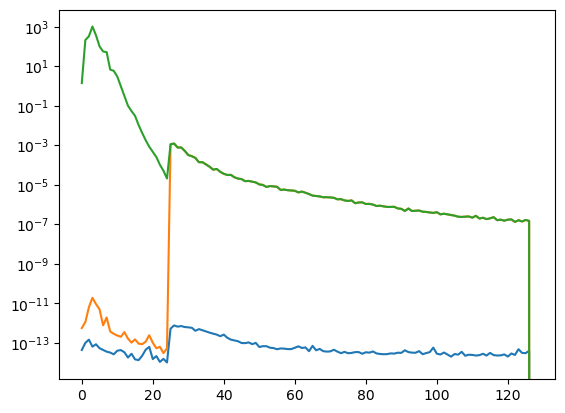

In [328]:
plt.plot(radial_psd((y1-y2))[1][0])
plt.plot(radial_psd((x0-y1))[1][0])

plt.plot(radial_psd(y1)[1][0])
plt.yscale('log')

## Learning prediction from x0 estimates

In [5]:
model.eval()

statistics_eval_mode = {}

with torch.no_grad():
    all_batches_target = []
    all_batches_x0_estimates = []

    for batch_idx, sample in enumerate(train_loader):
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]

        prediction, all_x0_estimates = model(conditioning_frame, require_x0_estimate = True)

        all_batches_target.append(target_frame)
        all_batches_x0_estimates.append(all_x0_estimates)
        if batch_idx == 50 : break

    all_batches_x0_estimates = torch.stack(all_batches_x0_estimates)
    all_batches_target = torch.stack(all_batches_target)
    
    all_batches_x0_estimates = all_batches_x0_estimates.permute(1, 0, 2, 3, 4, 5) 
    s = all_batches_x0_estimates.shape
    all_batches_x0_estimates = all_batches_x0_estimates.reshape((s[0], -1, s[3], s[4], s[5]))

    s = all_batches_target.shape
    all_batches_target = all_batches_target.reshape((-1, s[2], s[3], s[4]))

In [7]:
all_batches_x0_estimates.shape, all_batches_target.shape

(torch.Size([100, 3264, 2, 64, 64]), torch.Size([3264, 2, 64, 64]))

In [14]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class IntermPredDataset(Dataset):
    def __init__(self, all_batches_x0_estimates, all_batches_target):
        super().__init__()
        
        self.all_batches_x0_estimates = all_batches_x0_estimates
        self.all_batches_target = all_batches_target

        print(s)
        # Precompute normalization stats
        #self.mean_x, self.std_x, self.mean_y, self.std_y = self.compute_stats()

    def __len__(self):
        return self.all_batches_target.shape[0]

    def __getitem__(self, index):
        t = torch.randint(0, self.all_batches_x0_estimates.shape[0]-1, size = (1,)).item()

        gt_x = self.all_batches_target[index]
        interm_pred = self.all_batches_x0_estimates[t, index]

        target = self.all_batches_x0_estimates[-1, index]

        #input = torch.cat((interm_pred - gt_x, gt_x), dim=0)
        input = target
        target = gt_x
        #input = interm_pred

        return input, t, target
    
train_interm_pred_ds = IntermPredDataset(all_batches_x0_estimates[:, :100], all_batches_target[:100])
train_interm_pred_dl = DataLoader(train_interm_pred_ds, batch_size=64, shuffle=True, num_workers=0)

val_interm_pred_ds = IntermPredDataset(all_batches_x0_estimates[:, :100], all_batches_target[:100])
val_interm_pred_dl = DataLoader(val_interm_pred_ds, batch_size=64, shuffle=True, num_workers=0)

torch.Size([51, 64, 2, 64, 64])
torch.Size([51, 64, 2, 64, 64])


In [15]:
import torch.optim as optim
from src.model import Unet

model_params = {
        "dim": 64,
        "out_dim": 2,
        "channels": 2,
        "dim_mults": [1, 1, 1],
        "use_convnext": True,
        "convnext_mult": 1,
        "with_time_emb": False
    }

model = Unet(**model_params).to(device)

optimizer = optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.MSELoss().to(device)

for epoch in range(1000):
    # (Training and validation loops remain unchanged)
    model.train()
    running_train_loss = 0.0
    for batch_idx, sample in enumerate(train_interm_pred_dl):
        inp, t, target = sample
        optimizer.zero_grad()
        pred = model(inp, None)[:, -2:]
        loss = criterion(pred, target)
        running_train_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_train_loss = running_train_loss / (batch_idx + 1)
    
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_idx_val, sample_val in enumerate(val_interm_pred_dl):
            inp, t, target = sample
            pred = model(inp, None)[:, -2:]
            loss = criterion(pred, target)
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / (batch_idx_val + 1) if (batch_idx_val + 1) > 0 else 0

    print(f"Epoch [{epoch+1}], Training Loss: {avg_train_loss:.8f}, Validation Loss: {avg_val_loss:.8f}")


Epoch [1], Training Loss: 1.31495947, Validation Loss: 1.47616792
Epoch [2], Training Loss: 1.07003185, Validation Loss: 0.49886259
Epoch [3], Training Loss: 0.42909768, Validation Loss: 0.26679662
Epoch [4], Training Loss: 0.24585797, Validation Loss: 0.20086169
Epoch [5], Training Loss: 0.17101249, Validation Loss: 0.12929150
Epoch [6], Training Loss: 0.12043111, Validation Loss: 0.10315798
Epoch [7], Training Loss: 0.10771202, Validation Loss: 0.09639195
Epoch [8], Training Loss: 0.09170699, Validation Loss: 0.08390588
Epoch [9], Training Loss: 0.08397782, Validation Loss: 0.07648019
Epoch [10], Training Loss: 0.07025507, Validation Loss: 0.06378219
Epoch [11], Training Loss: 0.06530930, Validation Loss: 0.05882796
Epoch [12], Training Loss: 0.05277294, Validation Loss: 0.04348027
Epoch [13], Training Loss: 0.04735688, Validation Loss: 0.05224608
Epoch [14], Training Loss: 0.04789389, Validation Loss: 0.03857266
Epoch [15], Training Loss: 0.03867515, Validation Loss: 0.03999742
Epoc

KeyboardInterrupt: 

### Demo given by GPT

In [442]:
import torch
import math

# --- Utilities ---
def make_freq_radius(H, W, device):
    fy = torch.fft.fftfreq(H, device=device)
    fx = torch.fft.fftfreq(W, device=device)
    FX, FY = torch.meshgrid(fx, fy, indexing="xy")
    return torch.sqrt(FX**2 + FY**2), FX, FY

def lowpass_field(u, k_c=0.1):
    U = torch.fft.fft2(u, dim=(-2, -1))
    H, W = u.shape[-2:]
    r, _, _ = make_freq_radius(H, W, u.device)
    mask = (r < k_c)
    U[..., ~mask] = 0
    return torch.fft.ifft2(U, dim=(-2, -1)).real

def highpass_field(u, k_c=0.1):
    U = torch.fft.fft2(u, dim=(-2, -1))
    H, W = u.shape[-2:]
    r, _, _ = make_freq_radius(H, W, u.device)
    mask = (r >= k_c)
    U[..., ~mask] = 0
    return torch.fft.ifft2(U, dim=(-2, -1)).real

def divergence_free_highfreq(shape, k_min=0.1, k_max=0.45, amp=0.02, device="cpu"):
    C,H,W = shape
    assert C==2
    r, FX, FY = make_freq_radius(H, W, device)
    band = (r >= k_min) & (r <= k_max)
    # random complex streamfunction
    psi_hat = torch.zeros((H,W), dtype=torch.complex64, device=device)
    phase = torch.exp(1j*2*math.pi*torch.rand((H,W), device=device))
    psi_hat[band] = phase[band]
    psi = torch.fft.ifft2(psi_hat).real
    # velocity: u = dψ/dy, v = -dψ/dx
    psi_fft = torch.fft.fft2(psi)
    u_hat = 1j*FY*psi_fft
    v_hat = -1j*FX*psi_fft
    u = torch.fft.ifft2(u_hat).real
    v = torch.fft.ifft2(v_hat).real
    vel = torch.stack([u,v], dim=0)
    vel = amp * vel / (vel.std() + 1e-8)
    return vel

# --- Multi-step evolution with nudging ---
def multi_step_demo(chain, u_ref, start_hf, steps=30, k_c=0.1, lam=0.2, high_amp=0.02, device="cuda"):
    C,H,W = u_ref.shape
    u_ref = u_ref.to(device)
    u_low_target = lowpass_field(u_ref, k_c=k_c)

    # Two initial states with same low modes, different high modes
    u_high_start = highpass_field(start_hf, k_c=k_c)
    x1 = u_low_target + u_high_start

    for i in range(steps):
        x1 = chain.trajectory(x1, length=1)[0]
        # weak nudging
        U1 = torch.fft.fft2(x1, dim=(-2,-1))
        U_low = torch.fft.fft2(u_low_target, dim=(-2,-1))
        r, _, _ = make_freq_radius(H, W, device)
        mask = (r < k_c)
        U1[..., mask] = (1-lam)*U1[..., mask] + lam*U_low[..., mask]
        print(U1[..., r>=k_c])
        x1 = torch.fft.ifft2(U1, dim=(-2,-1)).real
        # small high-freq perturbation
        #if i < 27:
        #    x1 = x1 + divergence_free_highfreq(u_ref.shape, k_min=k_c, k_max=0.45, amp=high_amp, device=device)
        #    x2 = x2 + divergence_free_highfreq(u_ref.shape, k_min=k_c, k_max=0.45, amp=high_amp, device=device)

    return x1, u_low_target


In [486]:
# 1. Get reference fluid field
chain = KolmogorovFlow(size=256, dt=0.2)
x0 = chain.prior()  # shape (2, 256, 256)
x0 = chain.trajectory(x0, length=64)[-1]

chain = KolmogorovFlow(size=256, dt=0.01)
start_hf = chain.trajectory(x0, length=1)[0]

# 2. Run multi-step demo
y1, u_low = multi_step_demo(chain, x0, start_hf, steps=100, k_c=0.1, lam=1, high_amp=0.02, device="cpu")

# 3. Compare low and high frequencies
U1 = torch.fft.fft2(y1, dim=(-2,-1))
U2 = torch.fft.fft2(x0, dim=(-2,-1))
r, _, _ = make_freq_radius(256, 256, device="cpu")
low_mask = (r < 0.1)
high_mask = (r >= 0.1)

print("Low-freq correlation:", torch.corrcoef(torch.stack([U1[0][low_mask].real.flatten(), U2[0][low_mask].real.flatten()]))[0,1].item())
print("High-freq correlation:", torch.corrcoef(torch.stack([U1[0][high_mask].real.flatten(), U2[0][high_mask].real.flatten()]))[0,1].item())


tensor([[ 3.0715e+01-9.6334e+00j,  8.7889e+00+1.4456e+01j,
          9.6227e+00+1.3356e+00j,  ...,
          1.4175e+01-1.3223e+01j,  1.3291e+01-6.1869e+00j,
         -8.1723e+00-2.7861e+01j],
        [ 7.8678e-06+1.8328e-06j, -9.9838e-07+3.1292e-06j,
          1.5587e-05+1.1921e-07j,  ...,
         -3.3157e-01+6.2343e-01j, -4.0286e-01+3.7885e-01j,
          6.3395e-01+9.4247e-01j]])
tensor([[ 3.3793e+01-1.1359e+01j,  9.8223e+00+1.2451e+01j,
          8.6801e+00-1.9111e+00j,  ...,
          1.5555e+01-1.3244e+01j,  1.5640e+01-5.0701e+00j,
         -8.0339e+00-2.6442e+01j],
        [ 4.2915e-06-2.8014e-06j,  1.6317e-05-3.8743e-07j,
          1.2994e-05-2.0266e-06j,  ...,
         -3.7886e-01+6.4049e-01j, -5.0019e-01+3.6667e-01j,
          6.1201e-01+8.9120e-01j]])
tensor([[ 3.5899e+01-1.3154e+01j,  1.0618e+01+1.0480e+01j,
          7.5431e+00-5.2512e+00j,  ...,
          1.6355e+01-1.3111e+01j,  1.7175e+01-3.6809e+00j,
         -7.7247e+00-2.4366e+01j],
        [-3.1590e-06-1.6749e-05j,

In [475]:
print(torch.mean((y1-x0)**2))
print(torch.mean((KolmogorovFlow.coarsen(y1,8)-KolmogorovFlow.coarsen(x0,8))**2))

tensor(7.6089e-05)
tensor(1.9330e-06)


In [487]:
chain = KolmogorovFlow(size=256, dt=0.01)

y1_chain = chain.trajectory(x0, length=10)
y2_chain = chain.trajectory(y1, length=10)

In [466]:
plt.plot(radial_psd(x0)[1][0])
plt.plot(radial_psd(lowpass_field(x0, k_c=0.1))[1][0])
plt.plot(radial_psd(y1)[1][0])
plt.yscale('log')


KeyboardInterrupt: 

In [488]:
print([(i, torch.mean((y1_chain[i] - y2_chain[i])**2)) for i in range(len(y1_chain))])

[(0, tensor(9.3361e-05)), (1, tensor(8.7556e-05)), (2, tensor(8.2180e-05)), (3, tensor(7.7204e-05)), (4, tensor(7.2600e-05)), (5, tensor(6.8344e-05)), (6, tensor(6.4415e-05)), (7, tensor(6.0790e-05)), (8, tensor(5.7451e-05)), (9, tensor(5.4382e-05))]


In [397]:
print([(i, torch.mean((y1_chain[i] - y2_chain[i])**2)) for i in range(len(y1_chain))])

[(0, tensor(0.0043)), (1, tensor(0.0039)), (2, tensor(0.0038)), (3, tensor(0.0039)), (4, tensor(0.0041)), (5, tensor(0.0045)), (6, tensor(0.0053)), (7, tensor(0.0065)), (8, tensor(0.0078)), (9, tensor(0.0089))]


### Generate Low Aligned Trajectories

In [365]:
import torch

# --- Utilities ---
def make_freq_radius(H, W, device):
    fy = torch.fft.fftfreq(H, device=device)
    fx = torch.fft.fftfreq(W, device=device)
    FX, FY = torch.meshgrid(fx, fy, indexing="xy")
    return torch.sqrt(FX**2 + FY**2)

def lowpass_field(u, k_c=0.1):
    """Extract low-frequency component of a field."""
    U = torch.fft.fft2(u, dim=(-2,-1))
    H, W = u.shape[-2:]
    r = make_freq_radius(H, W, u.device)
    mask = (r < k_c)
    U[..., ~mask] = 0
    return torch.fft.ifft2(U, dim=(-2,-1)).real

def spectral_nudge(u, u_low_target, k_c=0.1, lam=0.05):
    """Weakly nudge low-frequency modes of u towards u_low_target."""
    U = torch.fft.fft2(u, dim=(-2,-1))
    U_target = torch.fft.fft2(u_low_target, dim=(-2,-1))
    H, W = u.shape[-2:]
    r = make_freq_radius(H, W, u.device)
    mask = (r < k_c)
    U[..., mask] = (1 - lam) * U[..., mask] + lam * U_target[..., mask]
    return torch.fft.ifft2(U, dim=(-2,-1)).real

# --- Main function ---
def generate_low_aligned_trajectories(chain, num_candidates=50, k_c=0.1, low_tol=0.01, length=30, lam=0.05, device="cuda"):
    """
    Generate two fluid trajectories with nearly identical low-frequency modes.
    
    chain: simulator object with prior() and trajectory(x, length=1)
    num_candidates: number of trajectories to sample
    k_c: low-frequency cutoff
    low_tol: max relative difference allowed for low modes
    length: trajectory length
    lam: weak nudging parameter for fine alignment
    """
    # Step 1: sample pool of candidate trajectories
    candidates = []
    lows = []
    for _ in range(num_candidates):
        x0 = chain.prior().to(device)
        traj = x0
        for _ in range(length):
            traj = chain.trajectory(traj, length=1)[0]
        candidates.append(traj)
        lows.append(lowpass_field(traj, k_c=k_c))
    
    # Step 2: search for two trajectories with similar low modes
    found = False
    for i in range(num_candidates):
        for j in range(i+1, num_candidates):
            rel_diff = torch.norm(lows[i] - lows[j]) / torch.norm(lows[i])
            if rel_diff < low_tol:
                y1, y2 = candidates[i], candidates[j]
                u_low = lows[i]
                found = True
                break
        if found:
            break
    if not found:
        raise RuntimeError("No pair of low-aligned trajectories found. Increase num_candidates or low_tol.")
    
    # Step 3 (optional): weak nudging for fine alignment
    y1 = spectral_nudge(y1, u_low, k_c=k_c, lam=lam)
    y2 = spectral_nudge(y2, u_low, k_c=k_c, lam=lam)
    
    return y1, y2, u_low


In [367]:
y1, y2, u_low = generate_low_aligned_trajectories(
    chain,
    num_candidates=10,
    k_c=0.1,
    low_tol=0.01,
    length=30,
    lam=0.05,
    device="cuda"
)

print(y1.shape, y2.shape)  # -> (2, 256, 256)

RuntimeError: No pair of low-aligned trajectories found. Increase num_candidates or low_tol.

### Create a dataset with added noise on high-frequencies input

In [72]:
device='cpu'

In [121]:
def make_freq_radius(H, W, device):
    fy = torch.fft.fftfreq(H, device=device)
    fx = torch.fft.fftfreq(W, device=device)
    FX, FY = torch.meshgrid(fx, fy, indexing="xy")
    return torch.sqrt(FX**2 + FY**2)

H = 256
W = 256
C = 2
# different high-freq seeds
def highfreq_noise(shape, k_min, k_max, amp=0.05):
    U = torch.zeros(shape, dtype=torch.complex64, device=device)
    r = make_freq_radius(H, W, device)[0]
    band = (r >= k_min) & (r <= k_max)
    phase = torch.exp(1j * 2 * torch.pi * torch.rand(shape, device=device))
    for c in range(C):
        U[c][band] = phase[c][band]  # apply mask per channel
    u = torch.fft.ifft2(U, dim=(-2, -1)).real
    return amp * u / (u.std() + 1e-8)

def lowpass_field(u, k_c=0.1):
    U = torch.fft.fft2(u, dim=(-2, -1))
    H, W = u.shape[-2:]
    r = make_freq_radius(H, W, u.device)
    mask = (r < k_c)
    U[..., ~mask] = 0
    return torch.fft.ifft2(U, dim=(-2, -1)).real

def highpass_field(u, k_c=0.1):
    U = torch.fft.fft2(u, dim=(-2, -1))
    H, W = u.shape[-2:]
    r = make_freq_radius(H, W, u.device)
    mask = (r >= k_c)
    U[..., ~mask] = 0
    return torch.fft.ifft2(U, dim=(-2, -1)).real

In [316]:
chain = KolmogorovFlow(size=256, dt=0.2, reynolds = 5e3)
x0 = chain.prior().to(device=device)  # shape (2, 256, 256)
x0 = chain.trajectory(x0, length=64)[-1]

In [302]:
small_chain = KolmogorovFlow(size=256, dt=0.01)

In [337]:
noisy_x0_0 = x0 + highfreq_noise(x0.shape, k_min=0.5, k_max=10000, amp=1)
noisy_x0_1 = x0 + highfreq_noise(x0.shape, k_min=0.5, k_max=10000, amp=1)

#noisy_x0_0 = lowpass_field(x0, k_c=0.4) + highpass_field(small_chain.trajectory(x0, length=1)[0], k_c=0.4)

y_noised_0 = chain.trajectory(noisy_x0_0, length=1)[0]
y_noised_1 = chain.trajectory(noisy_x0_1, length=1)[0]
y_gt = chain.trajectory(x0, length=1)[0]

In [338]:
print(torch.mean((noisy_x0_0-noisy_x0_1)**2))
print(torch.mean((KolmogorovFlow.coarsen(noisy_x0_0, 8) - KolmogorovFlow.coarsen(noisy_x0_1, 8))**2))

tensor(1.9681)
tensor(4.4065e-15)


In [339]:
print(torch.mean((y_noised_0-y_noised_1)**2))
print(torch.mean((KolmogorovFlow.coarsen(y_noised_0, 4) - KolmogorovFlow.coarsen(y_noised_1, 4))**2))

tensor(0.0002)
tensor(5.2832e-05)


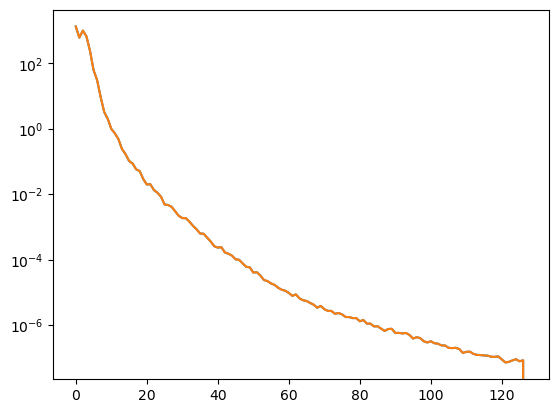

In [325]:
plt.plot(radial_psd(x0)[1][0])
plt.plot(radial_psd(noisy_x0_0)[1][0])
plt.yscale('log')

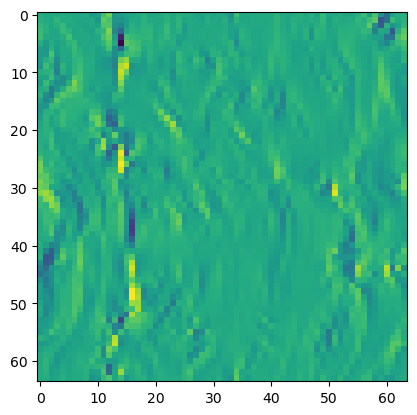

In [335]:
plt.imshow(KolmogorovFlow.coarsen(y_noised_1, 4)[0] - KolmogorovFlow.coarsen(y_noised_0, 4)[0])

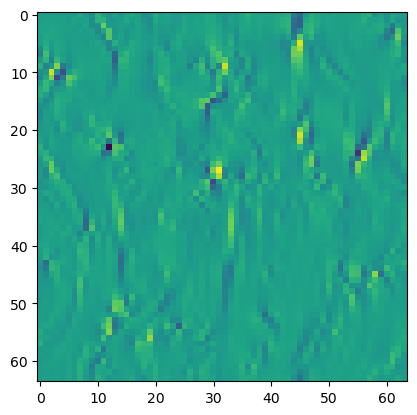

In [340]:
plt.imshow(KolmogorovFlow.coarsen(y_noised_1, 4)[0] - KolmogorovFlow.coarsen(y_noised_0, 4)[0])

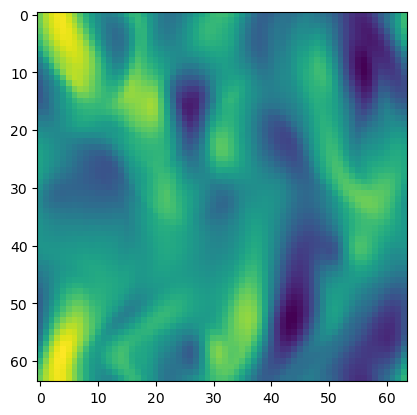

In [341]:
plt.imshow(KolmogorovFlow.coarsen(y_noised_1, 4)[0])

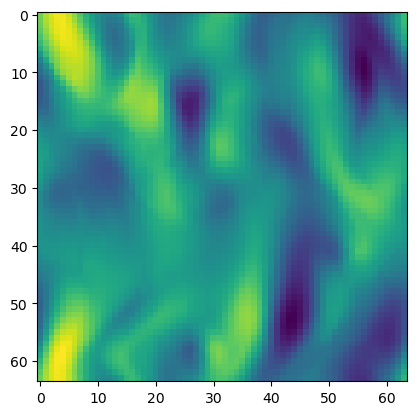

In [332]:
plt.imshow(KolmogorovFlow.coarsen(y_noised_0, 4)[0])

### Creating a Stochastic N-S dataset

In [25]:
import jax
import jax.numpy as jnp
import jax_cfd.base as cfd
import math


class SpectralStochasticFlow:
    def __init__(self, size=256, dt=0.01, reynolds=40_000, seed=0,
                 noise_magnitude=1.0, kmin=3, kmax=5):
        self.grid = cfd.grids.Grid(
            shape=(size, size),
            domain=((0, 2 * math.pi), (0, 2 * math.pi)),
        )
        self.bc = cfd.boundaries.periodic_boundary_conditions(2)
        self.dt = dt
        self.reynolds = reynolds
        self.noise_magnitude = noise_magnitude
        self.kmin = kmin
        self.kmax = kmax
        self.key = jax.random.PRNGKey(seed)

        # Navier–Stokes step without explicit forcing
        dt_min = cfd.equations.stable_time_step(
            grid=self.grid,
            max_velocity=5.0,
            max_courant_number=0.5,
            viscosity=1 / self.reynolds,
        )
        steps = 1 if dt_min > self.dt else math.ceil(self.dt / dt_min)
        self.base_step = cfd.funcutils.repeated(
            f=cfd.equations.semi_implicit_navier_stokes(
                grid=self.grid,
                forcing='kolmogorov', 
                dt=self.dt / steps,
                density=1.0,
                viscosity=1 / self.reynolds,
            ),
            steps=steps,
        )

    def _spectral_noise(self, key):
        """Generate random noise in Fourier space, restricted to [kmin, kmax]."""
        nx, ny = self.grid.shape
        kx = jnp.fft.fftfreq(nx) * nx
        ky = jnp.fft.rfftfreq(ny) * ny
        KX, KY = jnp.meshgrid(kx, ky, indexing="ij")
        k = jnp.sqrt(KX**2 + KY**2)
        mask = (k >= self.kmin) & (k <= self.kmax)

        def one_component(subkey):
            coeffs = jax.random.normal(subkey, (nx, ny)) * self.noise_magnitude
            coeffs_fft = jnp.fft.rfft2(coeffs)
            coeffs_fft = coeffs_fft * mask
            return jnp.fft.irfft2(coeffs_fft, s=(nx, ny))

        key_u, key_v = jax.random.split(key)
        fx = one_component(key_u)
        fy = one_component(key_v)
        return jnp.stack([fx, fy])  # shape (2, nx, ny)

    def trajectory(self, x0, length=1):
        """Simulate trajectory with spectral noise added directly to the state."""
        state = x0
        traj = []
        key = self.key
        for _ in range(length):
            key, subkey = jax.random.split(key)
            noise = self._spectral_noise(subkey)
            state = self.base_step(state)  # evolve with Navier–Stokes
            state = state + noise          # 🚀 add spectral noise directly
            traj.append(state)
        self.key = key
        return traj


In [26]:
prior_chain = KolmogorovFlow(size=256, dt=0.2)
x0 = prior_chain.prior()

chain = SpectralStochasticFlow(size=256, dt=0.2, noise_magnitude=1.0, kmin=3, kmax=5)
y1_chain = chain.trajectory(x0, length=1)


TypeError: Argument 'tensor([[[ 0.9106,  0.8394,  0.7570,  ...,  1.0405,  1.0123,  0.9687],
         [ 0.9128,  0.8427,  0.7617,  ...,  1.0413,  1.0133,  0.9702],
         [ 0.9117,  0.8429,  0.7635,  ...,  1.0376,  1.0103,  0.9680],
         ...,
         [ 0.8776,  0.8054,  0.7207,  ...,  1.0052,  0.9787,  0.9358],
         [ 0.8935,  0.8213,  0.7370,  ...,  1.0231,  0.9956,  0.9521],
         [ 0.9043,  0.8324,  0.7489,  ...,  1.0347,  1.0066,  0.9629]],

        [[-0.3960, -0.4030, -0.4111,  ..., -0.3783, -0.3840, -0.3898],
         [-0.3284, -0.3317, -0.3364,  ..., -0.3236, -0.3246, -0.3261],
         [-0.2527, -0.2528, -0.2547,  ..., -0.2590, -0.2560, -0.2538],
         ...,
         [-0.5522, -0.5733, -0.5942,  ..., -0.4849, -0.5083, -0.5307],
         [-0.5074, -0.5233, -0.5396,  ..., -0.4583, -0.4753, -0.4915],
         [-0.4556, -0.4667, -0.4787,  ..., -0.4231, -0.4340, -0.4448]]])' of type '<class 'torch.Tensor'>' is not a valid JAX type

In [344]:
def stochastic_forcing(key, amplitude=0.1, k_max=4):
    def forcing_fn(t, grid):
        k = jax.random.fold_in(key, t)  # different random key per step
        return make_stochastic_forcing(k, grid, amplitude, k_max)
    return forcing_fn

In [345]:
nx = ny = 64
grid = grids.Grid((nx, ny), domain=((0, 2*jnp.pi), (0, 2*jnp.pi)))
dt = 1e-2

forcing_fn = stochastic_forcing(jax.random.PRNGKey(0), amplitude=0.05)

step_fn = equations.implicit_diffusion_navier_stokes(
    density=1.0,
    viscosity=1e-3,
    dt=dt,
    grid=grid,
    forcing=forcing_fn
)


In [348]:
import jax
import jax.numpy as jnp
from jax_cfd.base import grids, equations

# --------------------------
# 1. Grid and solver setup
# --------------------------
nx = ny = 64
grid = grids.Grid((nx, ny), domain=((0, 2*jnp.pi), (0, 2*jnp.pi)))
dt = 1e-2
viscosity = 1e-3

# --------------------------
# 2. Divergence-free stochastic forcing
# --------------------------
def make_stochastic_forcing(key, grid, amplitude=0.05, k_max=4):
    nx, ny = grid.shape
    kx = jnp.fft.fftfreq(nx) * nx
    ky = jnp.fft.fftfreq(ny) * ny
    KX, KY = jnp.meshgrid(kx, ky, indexing="ij")

    # Random Fourier coefficients
    noise = jax.random.normal(key, (nx, ny, 2))

    # Keep only low frequencies (large-scale forcing)
    mask = (KX**2 + KY**2) <= k_max**2
    mask = mask[..., None]
    noise = noise * mask

    # Project to divergence-free in Fourier space
    denom = KX**2 + KY**2 + 1e-6
    proj_x = noise[..., 0] - (KX * (KX*noise[...,0] + KY*noise[...,1]))/denom
    proj_y = noise[..., 1] - (KY * (KX*noise[...,0] + KY*noise[...,1]))/denom
    forcing_fft = jnp.stack([proj_x, proj_y], axis=-1)

    # Back to real space
    forcing = jnp.fft.ifft2(forcing_fft, axes=(0,1)).real
    return amplitude * forcing

def stochastic_forcing(key, amplitude=0.05, k_max=4):
    def forcing_fn(t, grid):
        k = jax.random.fold_in(key, t)  # different key per timestep
        return make_stochastic_forcing(k, grid, amplitude, k_max)
    return forcing_fn

forcing_fn = stochastic_forcing(jax.random.PRNGKey(0), amplitude=0.05, k_max=4)

# --------------------------
# 3. Navier-Stokes stepper
# --------------------------
step_fn = equations.implicit_diffusion_navier_stokes(
    density=1.0,
    viscosity=viscosity,
    dt=dt,
    grid=grid,
    forcing=forcing_fn
)

# --------------------------
# 4. Initialize divergence-free velocity
# --------------------------
def random_velocity_field(key, grid, k_max=8):
    nx, ny = grid.shape
    kx = jnp.fft.fftfreq(nx) * nx
    ky = jnp.fft.fftfreq(ny) * ny
    KX, KY = jnp.meshgrid(kx, ky, indexing="ij")

    noise = jax.random.normal(key, (nx, ny, 2))
    denom = KX**2 + KY**2 + 1e-6
    proj_x = noise[..., 0] - (KX * (KX*noise[...,0] + KY*noise[...,1]))/denom
    proj_y = noise[..., 1] - (KY * (KX*noise[...,0] + KY*noise[...,1]))/denom

    vel_fft = jnp.stack([proj_x, proj_y], axis=-1)
    vel = jnp.fft.ifft2(vel_fft, axes=(0,1)).real
    return grids.GridVariable(vel, grid)

# --------------------------
# 5. Single trajectory simulation
# --------------------------
def simulate_trajectory(key, length=100):
    key, subkey = jax.random.split(key)
    state = random_velocity_field(subkey, grid)
    traj = []
    for t in range(length):
        traj.append(state.array)
        state = step_fn(state)
    return jnp.stack(traj, axis=0)  # shape (T, nx, ny, 2)

# --------------------------
# 6. Generate dataset of multiple trajectories
# --------------------------
def generate_dataset(num_traj=10, length=100, seed=0):
    key = jax.random.PRNGKey(seed)
    dataset = []
    for i in range(num_traj):
        key, subkey = jax.random.split(key)
        traj = simulate_trajectory(subkey, length=length)
        dataset.append(traj)
    return jnp.stack(dataset, axis=0)  # shape (N, T, nx, ny, 2)

# Example: generate 5 trajectories of 50 timesteps each
data = generate_dataset(num_traj=5, length=50)
print("Dataset shape:", data.shape)  # (5, 50, 64, 64, 2)


ValueError: Expected array type to be GridArray, got <class 'jaxlib.xla_extension.ArrayImpl'>

In [5]:
from sda.mcs import StochasticNavierStokes

chain = StochasticNavierStokes(size=256, dt=0.2)
x0 = chain.prior().to(device=device)  # shape (2, 256, 256)
x0 = chain.trajectory(x0, length=64)[-1]

TypeError: GridArray.__init__() missing 1 required positional argument: 'offset'